<a href="https://colab.research.google.com/github/Davron030901/Machine_Learning/blob/main/Decision_Tree_Random_Forest_Guide.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌳 Decision Tree, Random Forest & Pruning 🌳
# + Real World Scenarios & Model Comparison

---

## What will you learn today?

| # | Topic |
|---|-------|
| 1 | What is a Decision Tree? |
| 2 | How does the tree decide? |
| 3 | Overfitting (memorizing vs learning) |
| 4 | Pruning (cutting the tree) |
| 5 | Random Forest (many trees voting) |
| 6 | Decision Tree vs Random Forest |
| 7 | Train both models with code |
| 8 | **REAL WORLD: Where do we use each model?** |
| 9 | **BIG COMPARISON: Linear vs Logistic vs Tree vs Forest** |
| 10 | **Why you do NOT need to know the math** |
| 11 | **Many real examples for your students** |

---

In [ ]:
!pip install numpy pandas matplotlib seaborn scikit-learn -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 13
print('Ready!')

Ready!


# 1️⃣ What is a Decision Tree?

---

**A Decision Tree = a flowchart of Yes/No questions.**

You already use it every day! When you decide what to wear:
1. Is it cold? YES → jacket. NO → next question.
2. Is it raining? YES → umbrella. NO → T-shirt.

The computer builds this flowchart **automatically** from data.

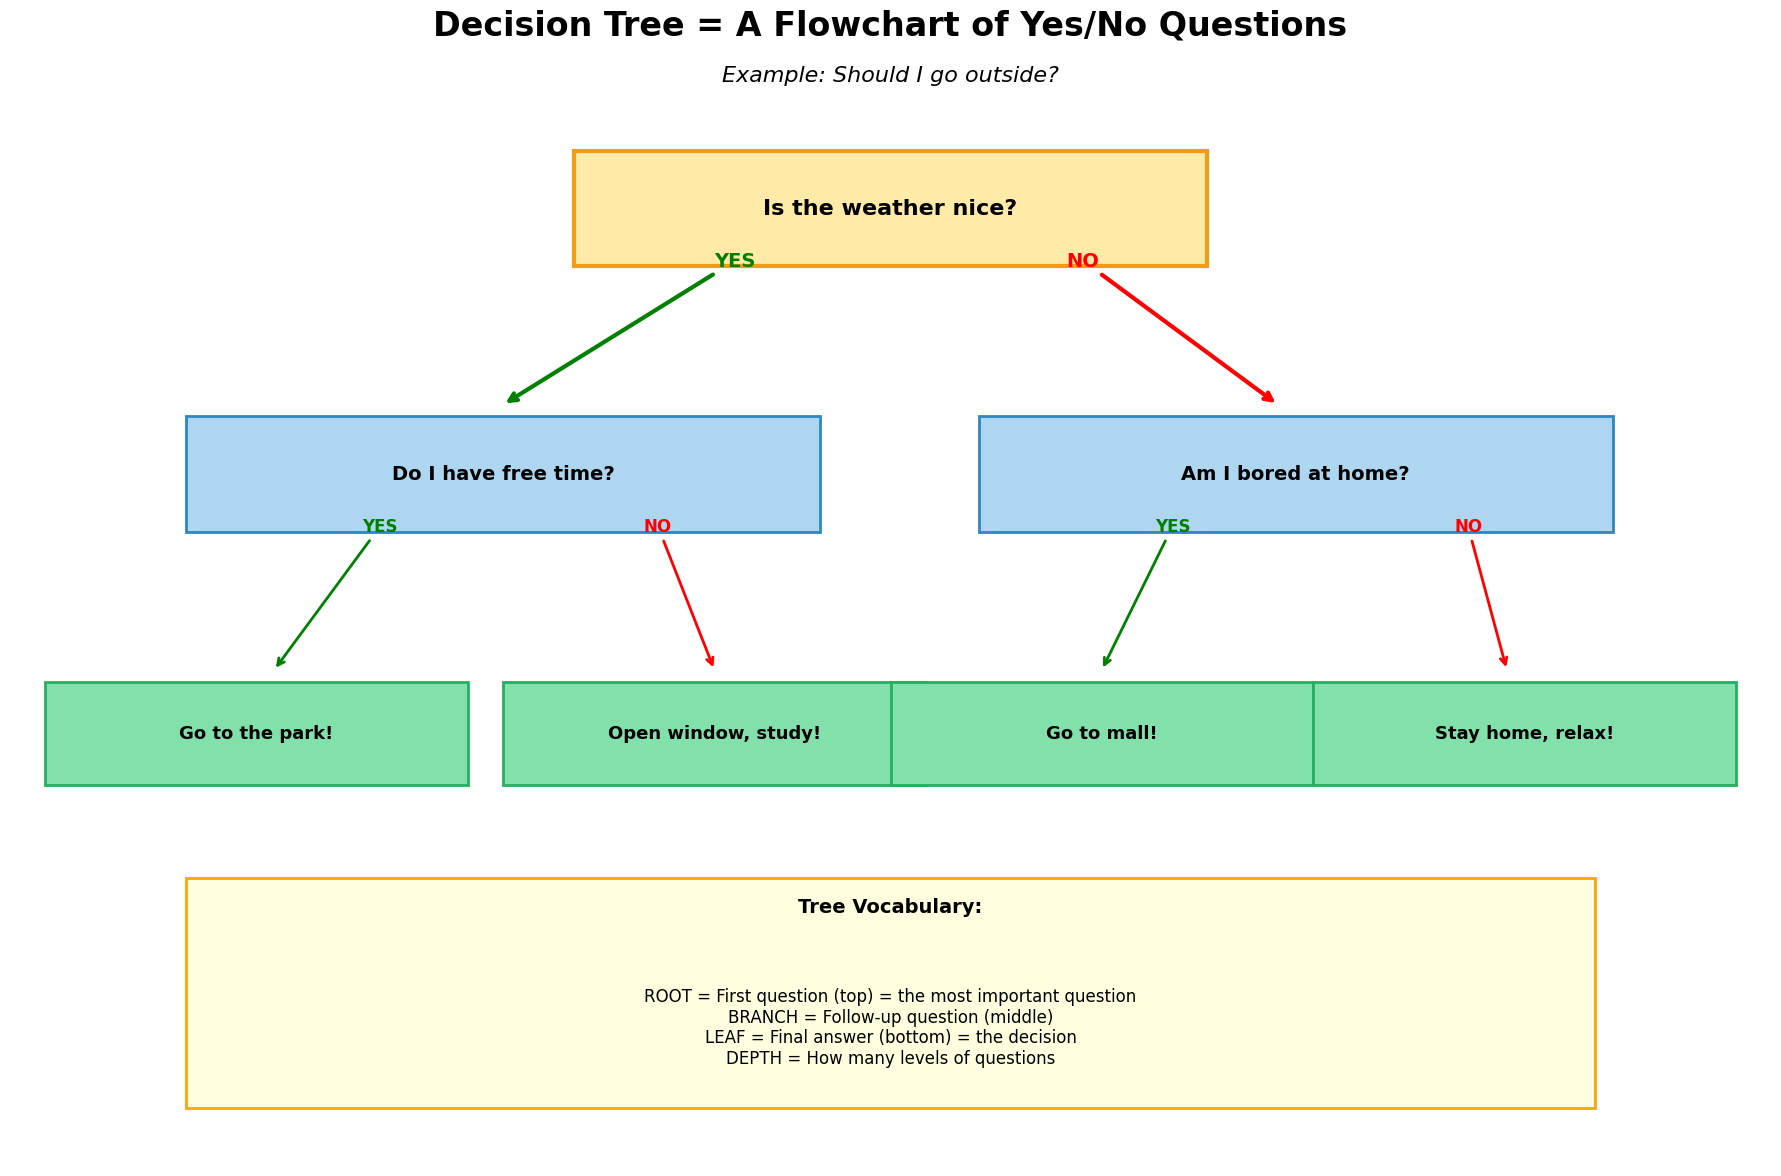

In [ ]:
# ---- VISUAL: Real Life Decision Tree ----

fig, ax = plt.subplots(figsize=(18, 12))
ax.axis('off')

ax.text(0.5, 0.98, 'Decision Tree = A Flowchart of Yes/No Questions', ha='center',
        fontsize=24, fontweight='bold', transform=ax.transAxes)
ax.text(0.5, 0.94, 'Example: Should I go outside?', ha='center',
        fontsize=16, transform=ax.transAxes, style='italic')

# Root
ax.add_patch(plt.Rectangle((0.32, 0.78), 0.36, 0.1, transform=ax.transAxes,
             facecolor='#FFEAA7', edgecolor='#F39C12', linewidth=3))
ax.text(0.5, 0.83, 'Is the weather nice?', ha='center', va='center',
        fontsize=16, fontweight='bold', transform=ax.transAxes)

# YES
ax.annotate('YES', xy=(0.28, 0.66), xytext=(0.40, 0.78), transform=ax.transAxes,
            fontsize=14, fontweight='bold', color='green',
            arrowprops=dict(arrowstyle='->', lw=3, color='green'))
ax.add_patch(plt.Rectangle((0.10, 0.55), 0.36, 0.1, transform=ax.transAxes,
             facecolor='#AED6F1', edgecolor='#2E86C1', linewidth=2))
ax.text(0.28, 0.60, 'Do I have free time?', ha='center', va='center',
        fontsize=14, fontweight='bold', transform=ax.transAxes)

ax.annotate('YES', xy=(0.15, 0.43), xytext=(0.20, 0.55), transform=ax.transAxes,
            fontsize=12, fontweight='bold', color='green',
            arrowprops=dict(arrowstyle='->', lw=2, color='green'))
ax.add_patch(plt.Rectangle((0.02, 0.33), 0.24, 0.09, transform=ax.transAxes,
             facecolor='#82E0AA', edgecolor='#27AE60', linewidth=2))
ax.text(0.14, 0.375, 'Go to the park!', ha='center', va='center',
        fontsize=13, fontweight='bold', transform=ax.transAxes)

ax.annotate('NO', xy=(0.40, 0.43), xytext=(0.36, 0.55), transform=ax.transAxes,
            fontsize=12, fontweight='bold', color='red',
            arrowprops=dict(arrowstyle='->', lw=2, color='red'))
ax.add_patch(plt.Rectangle((0.28, 0.33), 0.24, 0.09, transform=ax.transAxes,
             facecolor='#82E0AA', edgecolor='#27AE60', linewidth=2))
ax.text(0.40, 0.375, 'Open window, study!', ha='center', va='center',
        fontsize=13, fontweight='bold', transform=ax.transAxes)

# NO
ax.annotate('NO', xy=(0.72, 0.66), xytext=(0.60, 0.78), transform=ax.transAxes,
            fontsize=14, fontweight='bold', color='red',
            arrowprops=dict(arrowstyle='->', lw=3, color='red'))
ax.add_patch(plt.Rectangle((0.55, 0.55), 0.36, 0.1, transform=ax.transAxes,
             facecolor='#AED6F1', edgecolor='#2E86C1', linewidth=2))
ax.text(0.73, 0.60, 'Am I bored at home?', ha='center', va='center',
        fontsize=14, fontweight='bold', transform=ax.transAxes)

ax.annotate('YES', xy=(0.62, 0.43), xytext=(0.65, 0.55), transform=ax.transAxes,
            fontsize=12, fontweight='bold', color='green',
            arrowprops=dict(arrowstyle='->', lw=2, color='green'))
ax.add_patch(plt.Rectangle((0.50, 0.33), 0.24, 0.09, transform=ax.transAxes,
             facecolor='#82E0AA', edgecolor='#27AE60', linewidth=2))
ax.text(0.62, 0.375, 'Go to mall!', ha='center', va='center',
        fontsize=13, fontweight='bold', transform=ax.transAxes)

ax.annotate('NO', xy=(0.85, 0.43), xytext=(0.82, 0.55), transform=ax.transAxes,
            fontsize=12, fontweight='bold', color='red',
            arrowprops=dict(arrowstyle='->', lw=2, color='red'))
ax.add_patch(plt.Rectangle((0.74, 0.33), 0.24, 0.09, transform=ax.transAxes,
             facecolor='#82E0AA', edgecolor='#27AE60', linewidth=2))
ax.text(0.86, 0.375, 'Stay home, relax!', ha='center', va='center',
        fontsize=13, fontweight='bold', transform=ax.transAxes)

# Vocabulary
ax.add_patch(plt.Rectangle((0.10, 0.05), 0.80, 0.2, transform=ax.transAxes,
             facecolor='lightyellow', edgecolor='orange', linewidth=2))
ax.text(0.5, 0.22, 'Tree Vocabulary:', ha='center', fontsize=14, fontweight='bold',
        transform=ax.transAxes)
ax.text(0.5, 0.12, 'ROOT = First question (top) = the most important question\n'
        'BRANCH = Follow-up question (middle)\n'
        'LEAF = Final answer (bottom) = the decision\n'
        'DEPTH = How many levels of questions',
        ha='center', va='center', fontsize=12, transform=ax.transAxes)

plt.tight_layout()
plt.show()

---

# 2️⃣ How Does the Tree Pick the Best Question?

---

The tree tries ALL possible questions and picks the one that **separates data most cleanly**.

Think of it: 10 fruits (5 apples, 5 oranges). Which question separates them?
- "Is it round?" → BAD. Both are round. Still mixed.
- "Is it orange color?" → GOOD! Oranges go left, apples go right. Perfect!

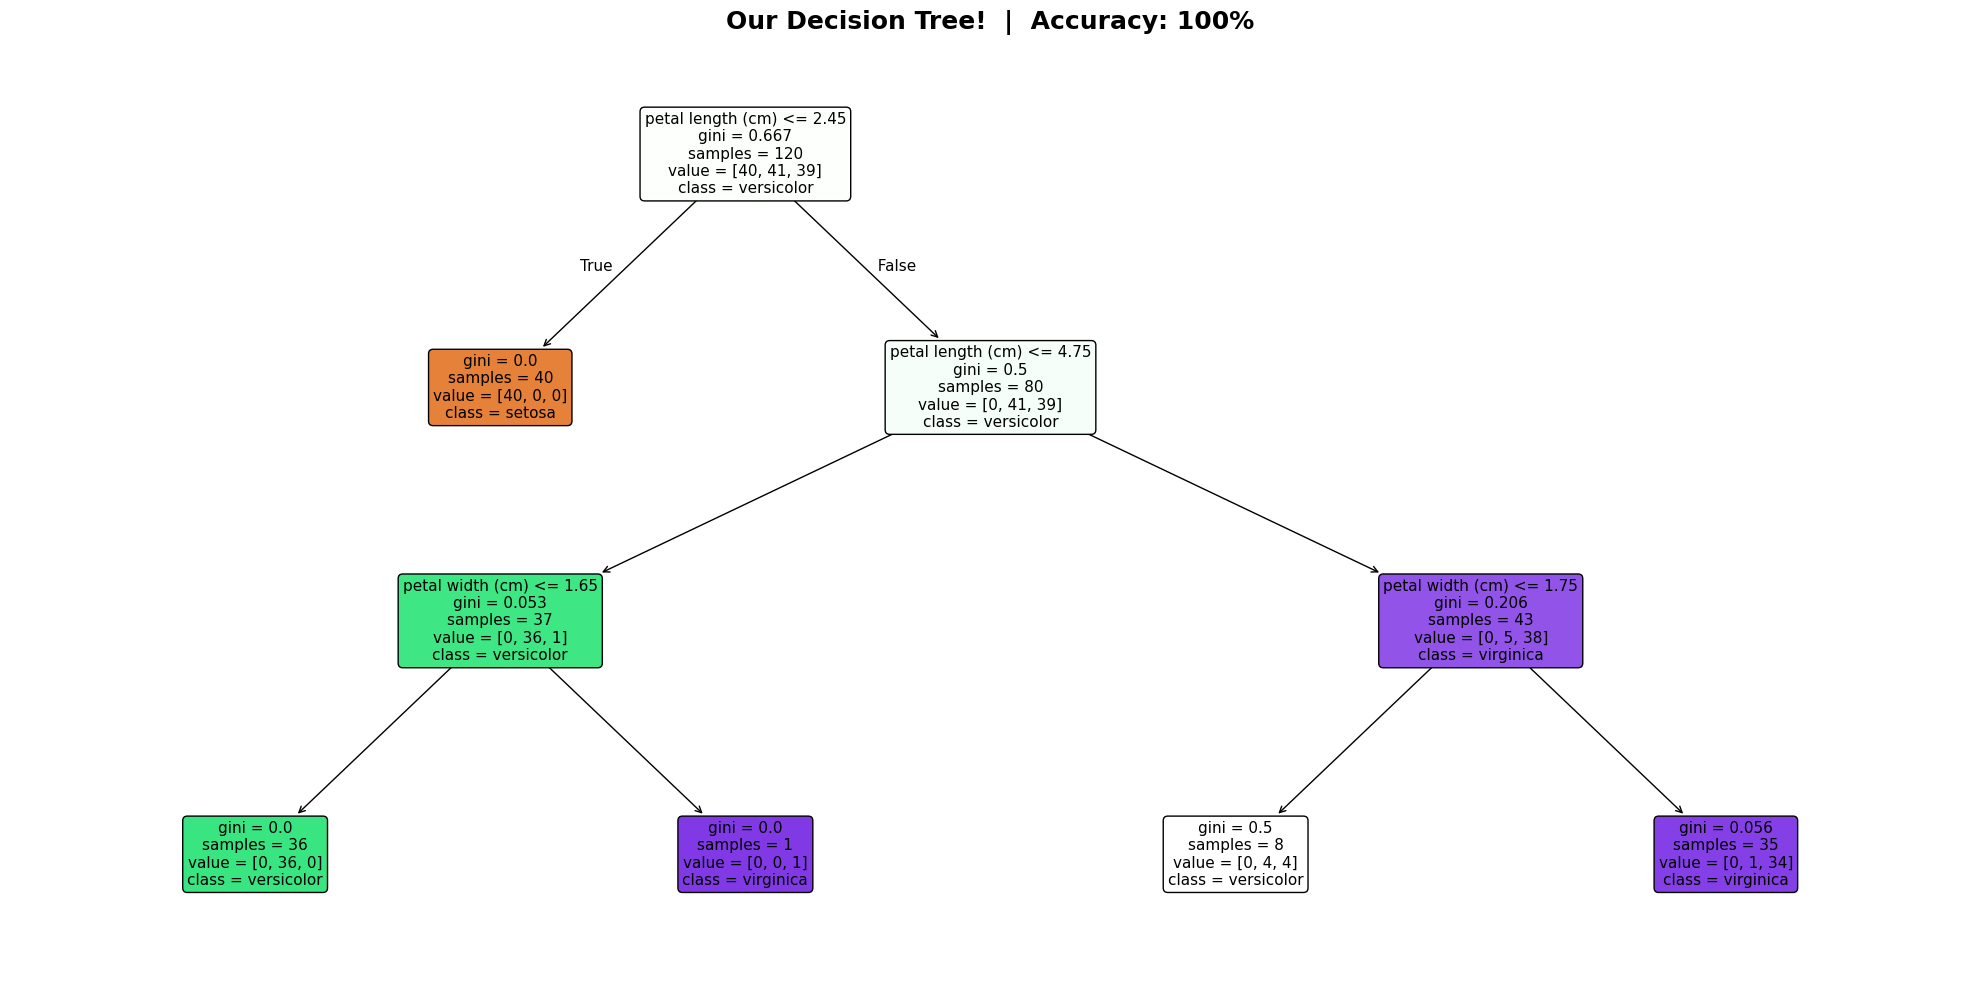

Read from top to bottom:
  TRUE (condition met) --> go LEFT
  FALSE (not met) --> go RIGHT
  Colored box at bottom = the answer (leaf)


In [ ]:
# ---- Build a real tree and SEE it ----

from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

iris = load_iris()
X_iris = pd.DataFrame(iris.data, columns=iris.feature_names)
y_iris = iris.target

X_tr, X_te, y_tr, y_te = train_test_split(X_iris, y_iris, test_size=0.2, random_state=42)

tree = DecisionTreeClassifier(max_depth=3, random_state=42)
tree.fit(X_tr, y_tr)

fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(tree, feature_names=iris.feature_names, class_names=iris.target_names,
          filled=True, rounded=True, fontsize=11, ax=ax)
ax.set_title(f'Our Decision Tree!  |  Accuracy: {accuracy_score(y_te, tree.predict(X_te)):.0%}',
             fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

print('Read from top to bottom:')
print('  TRUE (condition met) --> go LEFT')
print('  FALSE (not met) --> go RIGHT')
print('  Colored box at bottom = the answer (leaf)')

---

# 3️⃣ Overfitting - Memorizing vs Learning

---

**Overfitting = the model memorized training data but fails on new data.**

Like a student who memorized the textbook word-by-word but cannot answer a NEW question.

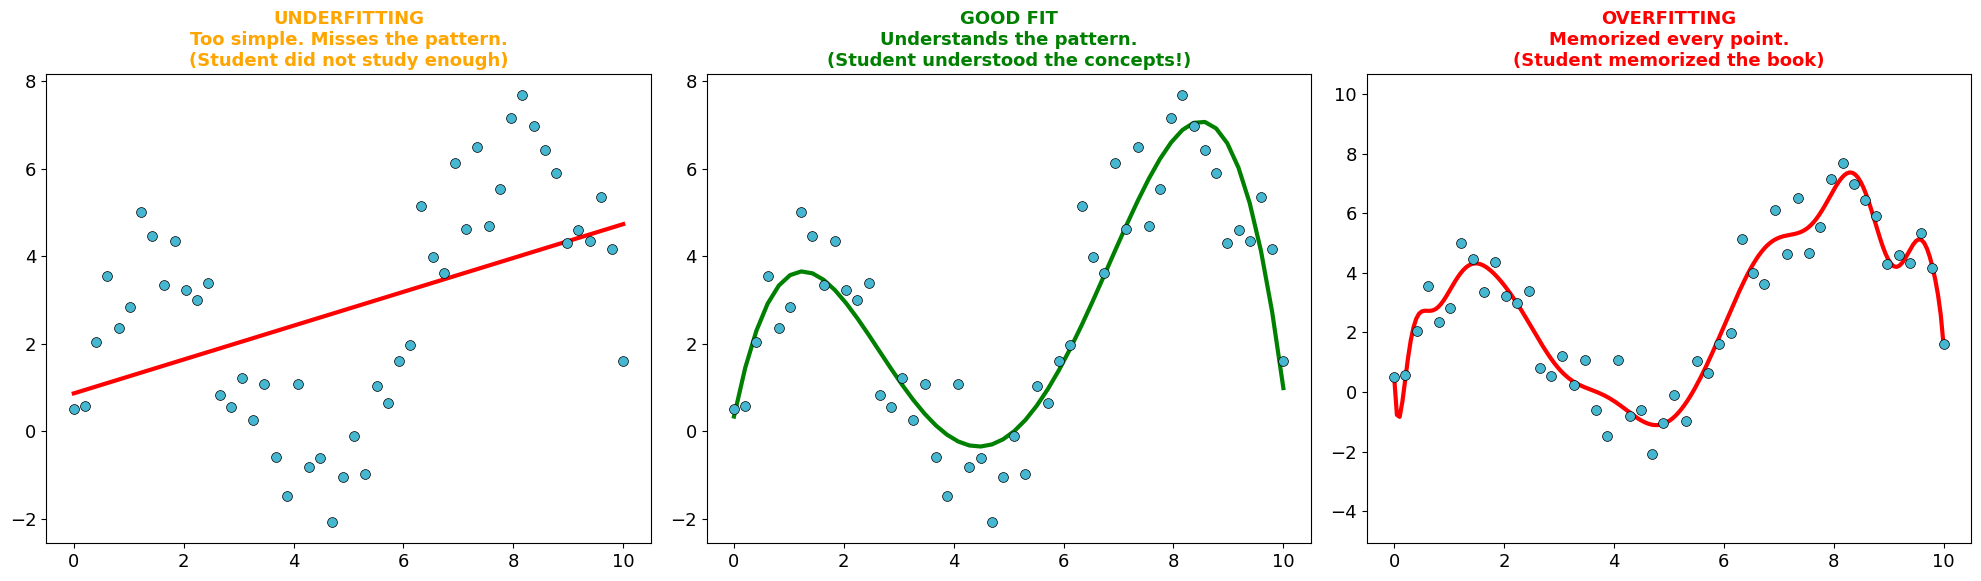

In [ ]:
# ---- Underfitting vs Good Fit vs Overfitting ----

np.random.seed(42)
x = np.linspace(0, 10, 50)
y_true = np.sin(x) * 3 + x * 0.5
y_noisy = y_true + np.random.normal(0, 1, len(x))

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

axes[0].scatter(x, y_noisy, c='#45B7D1', s=50, edgecolors='black', lw=0.5, zorder=5)
axes[0].plot(x, np.poly1d(np.polyfit(x, y_noisy, 1))(x), color='red', lw=3)
axes[0].set_title('UNDERFITTING\nToo simple. Misses the pattern.\n(Student did not study enough)',
                  fontsize=13, fontweight='bold', color='orange')

axes[1].scatter(x, y_noisy, c='#45B7D1', s=50, edgecolors='black', lw=0.5, zorder=5)
axes[1].plot(x, np.poly1d(np.polyfit(x, y_noisy, 4))(x), color='green', lw=3)
axes[1].set_title('GOOD FIT\nUnderstands the pattern.\n(Student understood the concepts!)',
                  fontsize=13, fontweight='bold', color='green')

axes[2].scatter(x, y_noisy, c='#45B7D1', s=50, edgecolors='black', lw=0.5, zorder=5)
x_s = np.linspace(0, 10, 200)
axes[2].plot(x_s, np.poly1d(np.polyfit(x, y_noisy, 20))(x_s), color='red', lw=3)
axes[2].set_ylim(min(y_noisy)-3, max(y_noisy)+3)
axes[2].set_title('OVERFITTING\nMemorized every point.\n(Student memorized the book)',
                  fontsize=13, fontweight='bold', color='red')

plt.tight_layout()
plt.show()

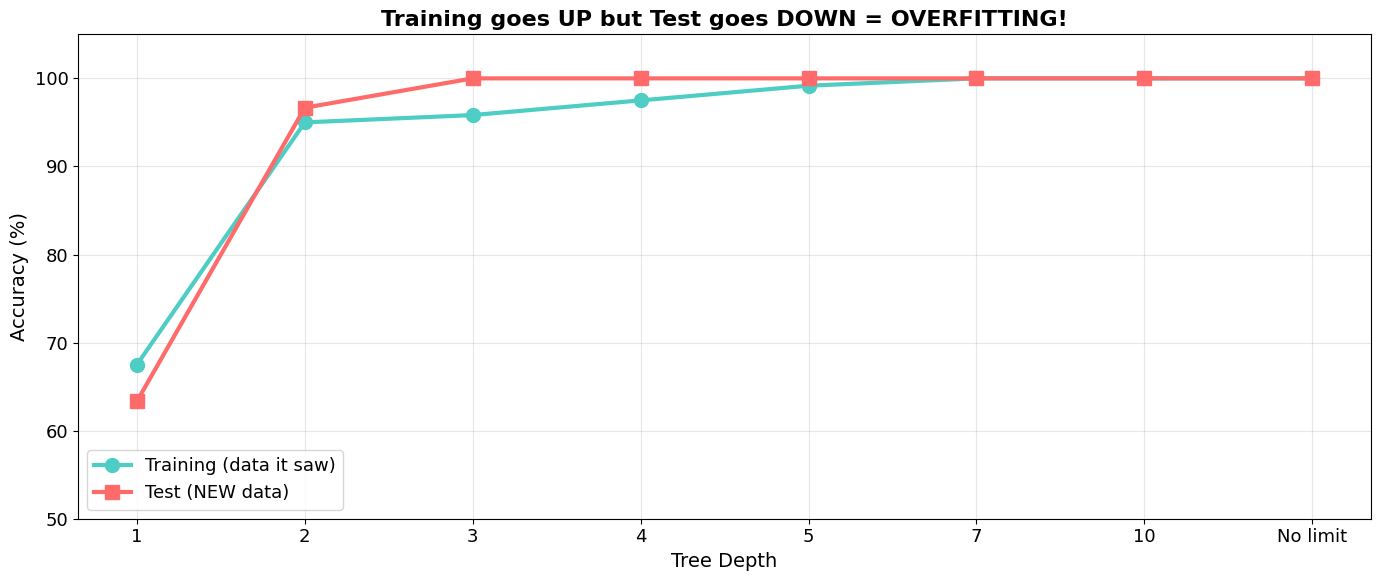

In [ ]:
# ---- Deeper tree = better? NOT always! ----

depths = [1, 2, 3, 4, 5, 7, 10, None]
train_a, test_a = [], []
for d in depths:
    t = DecisionTreeClassifier(max_depth=d, random_state=42)
    t.fit(X_tr, y_tr)
    train_a.append(accuracy_score(y_tr, t.predict(X_tr))*100)
    test_a.append(accuracy_score(y_te, t.predict(X_te))*100)

labels = [str(d) if d else 'No limit' for d in depths]
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(labels, train_a, marker='o', lw=3, markersize=10, color='#4ECDC4', label='Training (data it saw)')
ax.plot(labels, test_a, marker='s', lw=3, markersize=10, color='#FF6B6B', label='Test (NEW data)')
ax.set_xlabel('Tree Depth', fontsize=14)
ax.set_ylabel('Accuracy (%)', fontsize=14)
ax.set_title('Training goes UP but Test goes DOWN = OVERFITTING!', fontsize=16, fontweight='bold')
ax.legend(fontsize=13)
ax.set_ylim(50, 105)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

# 4️⃣ Pruning - Cutting the Tree

---

**Pruning = cutting branches so the tree is simpler and smarter.**

Like cutting a real garden tree so it grows healthier.

| Parameter | What it does | Real life |
|-----------|-------------|----------|
| `max_depth=3` | Max 3 levels | "Only 3 questions allowed" |
| `min_samples_split=10` | Need 10+ items to split | "Only split if 10+ people" |
| `min_samples_leaf=5` | Each leaf needs 5+ items | "Each team needs 5+ players" |

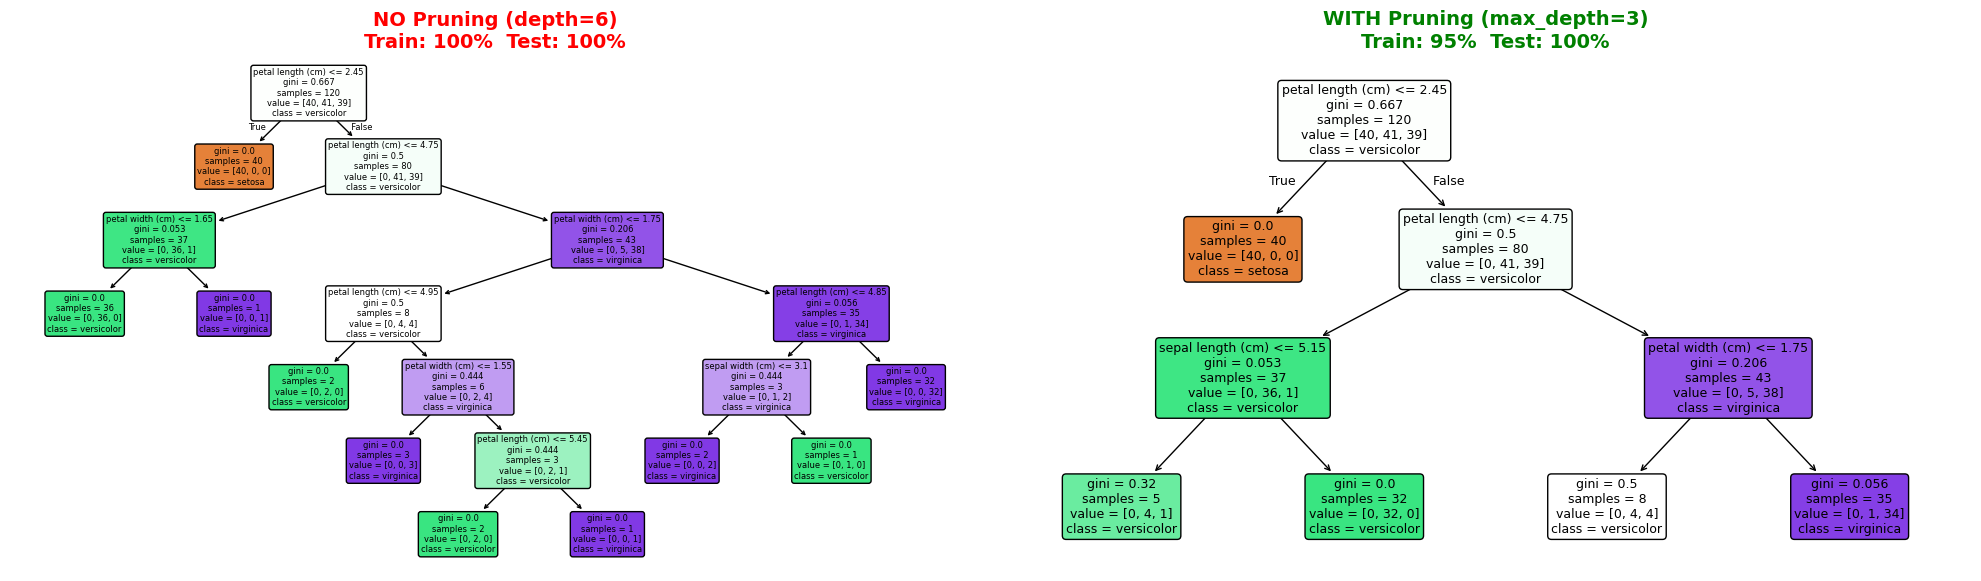

Pruned tree: simpler, almost same accuracy, works BETTER on new data!


In [ ]:
# ---- No pruning vs With pruning ----

fig, axes = plt.subplots(1, 2, figsize=(20, 6))

tree_deep = DecisionTreeClassifier(random_state=42)
tree_deep.fit(X_tr, y_tr)
plot_tree(tree_deep, feature_names=iris.feature_names, class_names=iris.target_names,
          filled=True, rounded=True, fontsize=6, ax=axes[0])
axes[0].set_title(f'NO Pruning (depth={tree_deep.get_depth()})\n'
                  f'Train: {accuracy_score(y_tr, tree_deep.predict(X_tr)):.0%}  '
                  f'Test: {accuracy_score(y_te, tree_deep.predict(X_te)):.0%}',
                  fontsize=14, fontweight='bold', color='red')

tree_pruned = DecisionTreeClassifier(max_depth=3, min_samples_leaf=5, random_state=42)
tree_pruned.fit(X_tr, y_tr)
plot_tree(tree_pruned, feature_names=iris.feature_names, class_names=iris.target_names,
          filled=True, rounded=True, fontsize=9, ax=axes[1])
axes[1].set_title(f'WITH Pruning (max_depth=3)\n'
                  f'Train: {accuracy_score(y_tr, tree_pruned.predict(X_tr)):.0%}  '
                  f'Test: {accuracy_score(y_te, tree_pruned.predict(X_te)):.0%}',
                  fontsize=14, fontweight='bold', color='green')

plt.tight_layout()
plt.show()
print('Pruned tree: simpler, almost same accuracy, works BETTER on new data!')

---

# 5️⃣ Random Forest - Many Trees Voting Together

---

**Random Forest = 100 decision trees that VOTE.**

Like asking 100 doctors instead of 1. Even if some are wrong, the majority is usually right.

### Why "Random"?
1. Each tree sees **random data** (different patients for each doctor)
2. Each tree sees **random features** (each doctor specializes in different things)

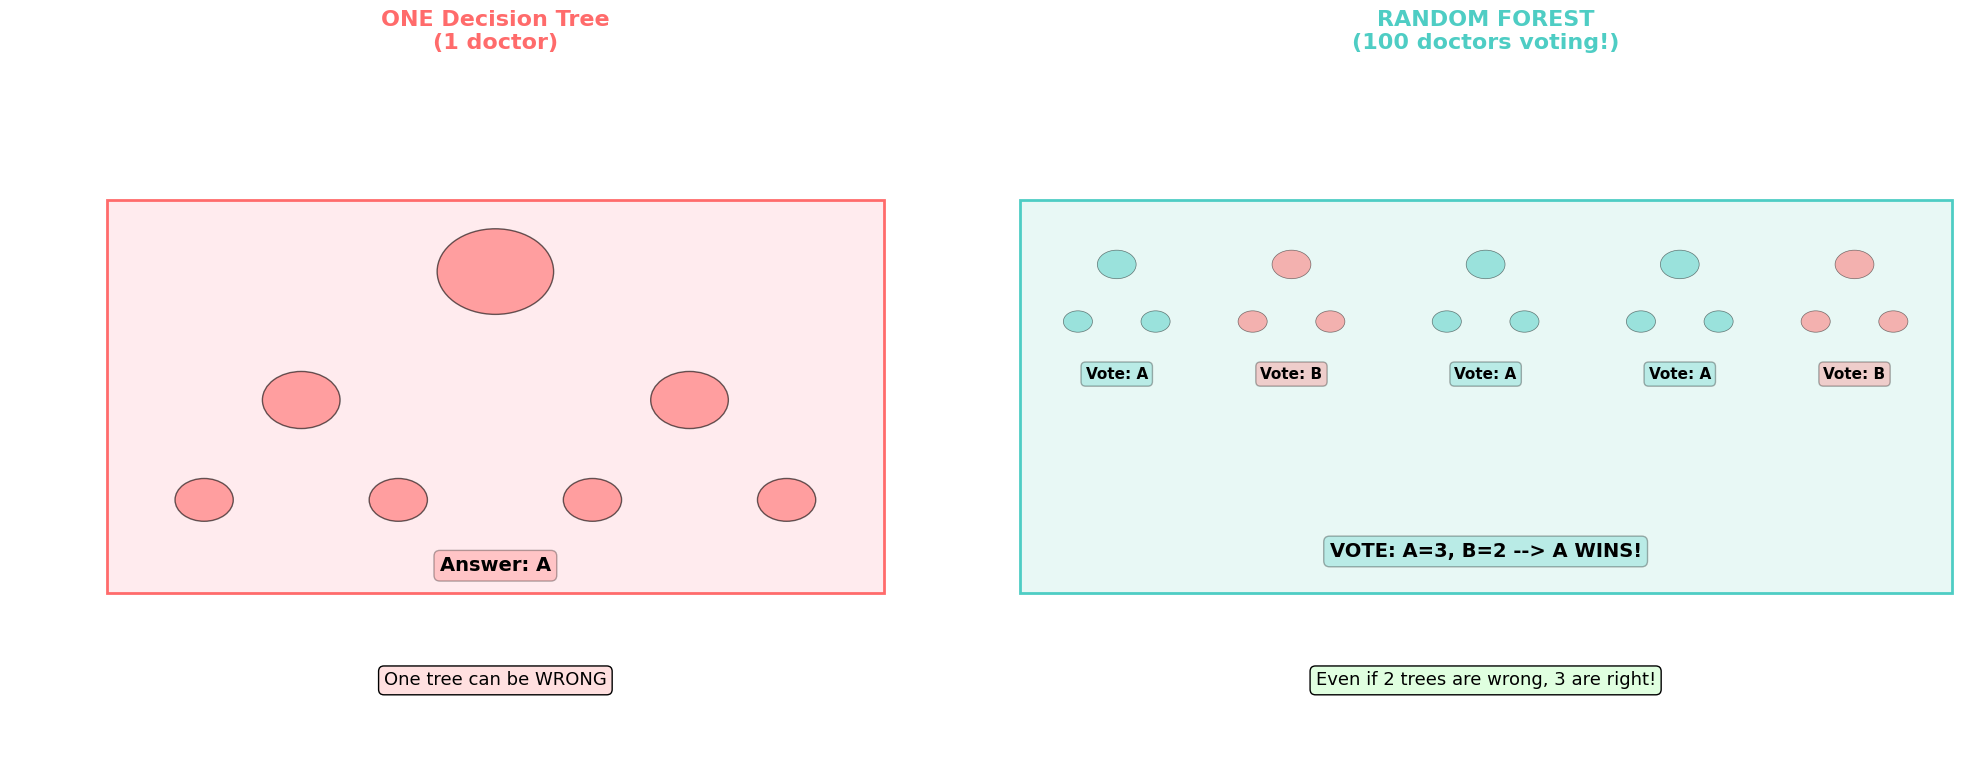

In [ ]:
# ---- VISUAL: 1 Tree vs Forest ----

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Single tree
ax = axes[0]
ax.axis('off')
ax.set_title('ONE Decision Tree\n(1 doctor)', fontsize=16, fontweight='bold', color='#FF6B6B')
ax.add_patch(plt.Rectangle((0.1, 0.25), 0.8, 0.55, transform=ax.transAxes,
             facecolor='#FFEBEE', edgecolor='#FF6B6B', lw=2))
for x, y, r in [(0.5,0.7,0.06),(0.3,0.52,0.04),(0.7,0.52,0.04),(0.2,0.38,0.03),(0.4,0.38,0.03),(0.6,0.38,0.03),(0.8,0.38,0.03)]:
    ax.add_patch(plt.Circle((x, y), r, transform=ax.transAxes, color='#FF6B6B', ec='black', lw=1, alpha=0.6))
ax.text(0.5, 0.28, 'Answer: A', ha='center', fontsize=14, fontweight='bold',
        transform=ax.transAxes, bbox=dict(boxstyle='round', facecolor='#FF6B6B', alpha=0.3))
ax.text(0.5, 0.12, 'One tree can be WRONG', ha='center', fontsize=13,
        transform=ax.transAxes, bbox=dict(boxstyle='round', facecolor='#FFE0E0'))

# Forest
ax = axes[1]
ax.axis('off')
ax.set_title('RANDOM FOREST\n(100 doctors voting!)', fontsize=16, fontweight='bold', color='#4ECDC4')
ax.add_patch(plt.Rectangle((0.02, 0.25), 0.96, 0.55, transform=ax.transAxes,
             facecolor='#E8F8F5', edgecolor='#4ECDC4', lw=2))

positions = [(0.12,0.65),(0.30,0.65),(0.50,0.65),(0.70,0.65),(0.88,0.65)]
votes = ['A','B','A','A','B']
cols = ['#4ECDC4','#FF6B6B','#4ECDC4','#4ECDC4','#FF6B6B']

for (tx,ty), v, c in zip(positions, votes, cols):
    for mx,my,mr in [(tx,ty+0.06,0.02),(tx-0.04,ty-0.02,0.015),(tx+0.04,ty-0.02,0.015)]:
        ax.add_patch(plt.Circle((mx,my), mr, transform=ax.transAxes, color=c, ec='black', lw=0.5, alpha=0.5))
    ax.text(tx, ty-0.10, f'Vote: {v}', ha='center', fontsize=11, fontweight='bold',
            transform=ax.transAxes, bbox=dict(boxstyle='round', facecolor=c, alpha=0.3))

ax.text(0.50, 0.30, 'VOTE: A=3, B=2 --> A WINS!', ha='center', fontsize=14,
        fontweight='bold', transform=ax.transAxes,
        bbox=dict(boxstyle='round', facecolor='#4ECDC4', alpha=0.3))
ax.text(0.50, 0.12, 'Even if 2 trees are wrong, 3 are right!', ha='center', fontsize=13,
        transform=ax.transAxes, bbox=dict(boxstyle='round', facecolor='#E0FFE0'))

plt.tight_layout()
plt.show()

---

# 6️⃣ Decision Tree vs Random Forest

---

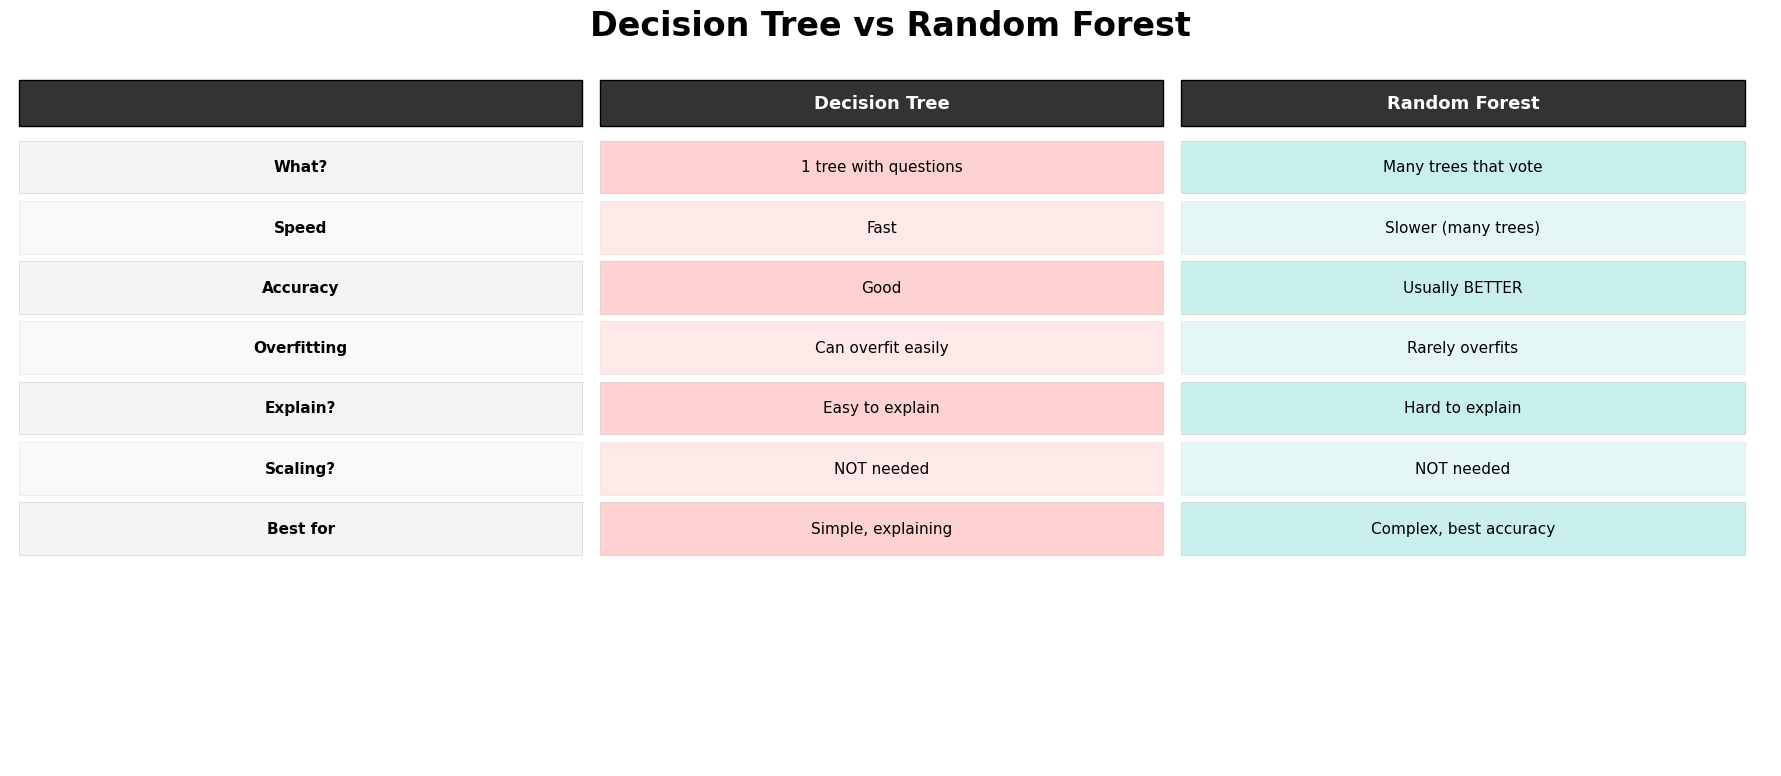

In [ ]:
# ---- Comparison table ----

fig, ax = plt.subplots(figsize=(18, 8))
ax.axis('off')
ax.text(0.5, 0.97, 'Decision Tree vs Random Forest', ha='center',
        fontsize=24, fontweight='bold', transform=ax.transAxes)

headers = ['', 'Decision Tree', 'Random Forest']
rows = [
    ['What?', '1 tree with questions', 'Many trees that vote'],
    ['Speed', 'Fast', 'Slower (many trees)'],
    ['Accuracy', 'Good', 'Usually BETTER'],
    ['Overfitting', 'Can overfit easily', 'Rarely overfits'],
    ['Explain?', 'Easy to explain', 'Hard to explain'],
    ['Scaling?', 'NOT needed', 'NOT needed'],
    ['Best for', 'Simple, explaining', 'Complex, best accuracy'],
]

for j, h in enumerate(headers):
    ax.add_patch(plt.Rectangle((j*0.33+0.005, 0.85), 0.32, 0.06, transform=ax.transAxes,
                 facecolor='#333', edgecolor='black', lw=1))
    ax.text(j*0.33+0.165, 0.88, h, ha='center', va='center', fontsize=13,
            fontweight='bold', color='white', transform=ax.transAxes)

for i, row in enumerate(rows):
    for j, val in enumerate(row):
        colors = ['#ddd', '#FF6B6B', '#4ECDC4']
        alpha = 0.3 if i % 2 == 0 else 0.15
        ax.add_patch(plt.Rectangle((j*0.33+0.005, 0.76-i*0.08), 0.32, 0.07,
                     transform=ax.transAxes, facecolor=colors[j], alpha=alpha,
                     edgecolor='gray', lw=0.5))
        ax.text(j*0.33+0.165, 0.795-i*0.08, val, ha='center', va='center',
                fontsize=11, fontweight='bold' if j==0 else 'normal', transform=ax.transAxes)

plt.tight_layout()
plt.show()

---

# 7️⃣ Train Both Models - Full Code

---

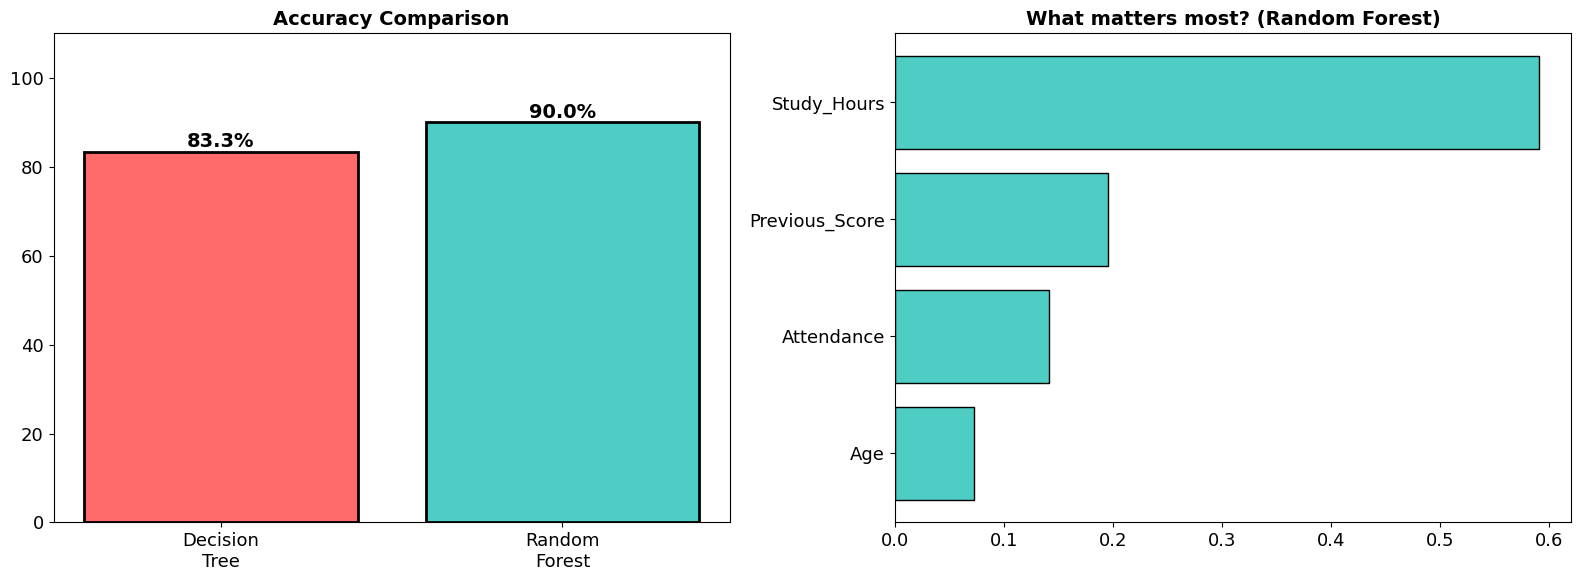

Decision Tree: 83.3%  |  Random Forest: 90.0%


In [ ]:
# Create student data
np.random.seed(42)
n = 300
study = np.random.uniform(1, 12, n)
attend = np.random.uniform(40, 100, n)
prev = np.random.uniform(30, 100, n)
age = np.random.randint(18, 40, n)
score = study * 5 + attend * 0.3 + prev * 0.3 + np.random.normal(0, 10, n)
passed = (score > 65).astype(int)

X = pd.DataFrame({'Study_Hours': study, 'Attendance': attend, 'Previous_Score': prev, 'Age': age})
y = passed
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train both
from sklearn.ensemble import RandomForestClassifier

dt = DecisionTreeClassifier(max_depth=4, min_samples_leaf=10, random_state=42)
dt.fit(X_train, y_train)

rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf.fit(X_train, y_train)

dt_acc = accuracy_score(y_test, dt.predict(X_test))
rf_acc = accuracy_score(y_test, rf.predict(X_test))

# Compare
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

bars = axes[0].bar(['Decision\nTree', 'Random\nForest'], [dt_acc*100, rf_acc*100],
                   color=['#FF6B6B', '#4ECDC4'], edgecolor='black', lw=2)
axes[0].set_ylim(0, 110)
axes[0].set_title('Accuracy Comparison', fontsize=14, fontweight='bold')
for bar, a in zip(bars, [dt_acc*100, rf_acc*100]):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                 f'{a:.1f}%', ha='center', fontsize=14, fontweight='bold')

imp = rf.feature_importances_
idx = np.argsort(imp)
axes[1].barh(range(len(idx)), imp[idx], color='#4ECDC4', edgecolor='black', lw=1)
axes[1].set_yticks(range(len(idx)))
axes[1].set_yticklabels([X.columns[i] for i in idx])
axes[1].set_title('What matters most? (Random Forest)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()
print(f'Decision Tree: {dt_acc:.1%}  |  Random Forest: {rf_acc:.1%}')

---

# 8️⃣ REAL WORLD: Where Do We Use Each Model?

---

## This is what students always ask: "But when do I use this in REAL LIFE?"

Here are REAL examples from REAL companies.

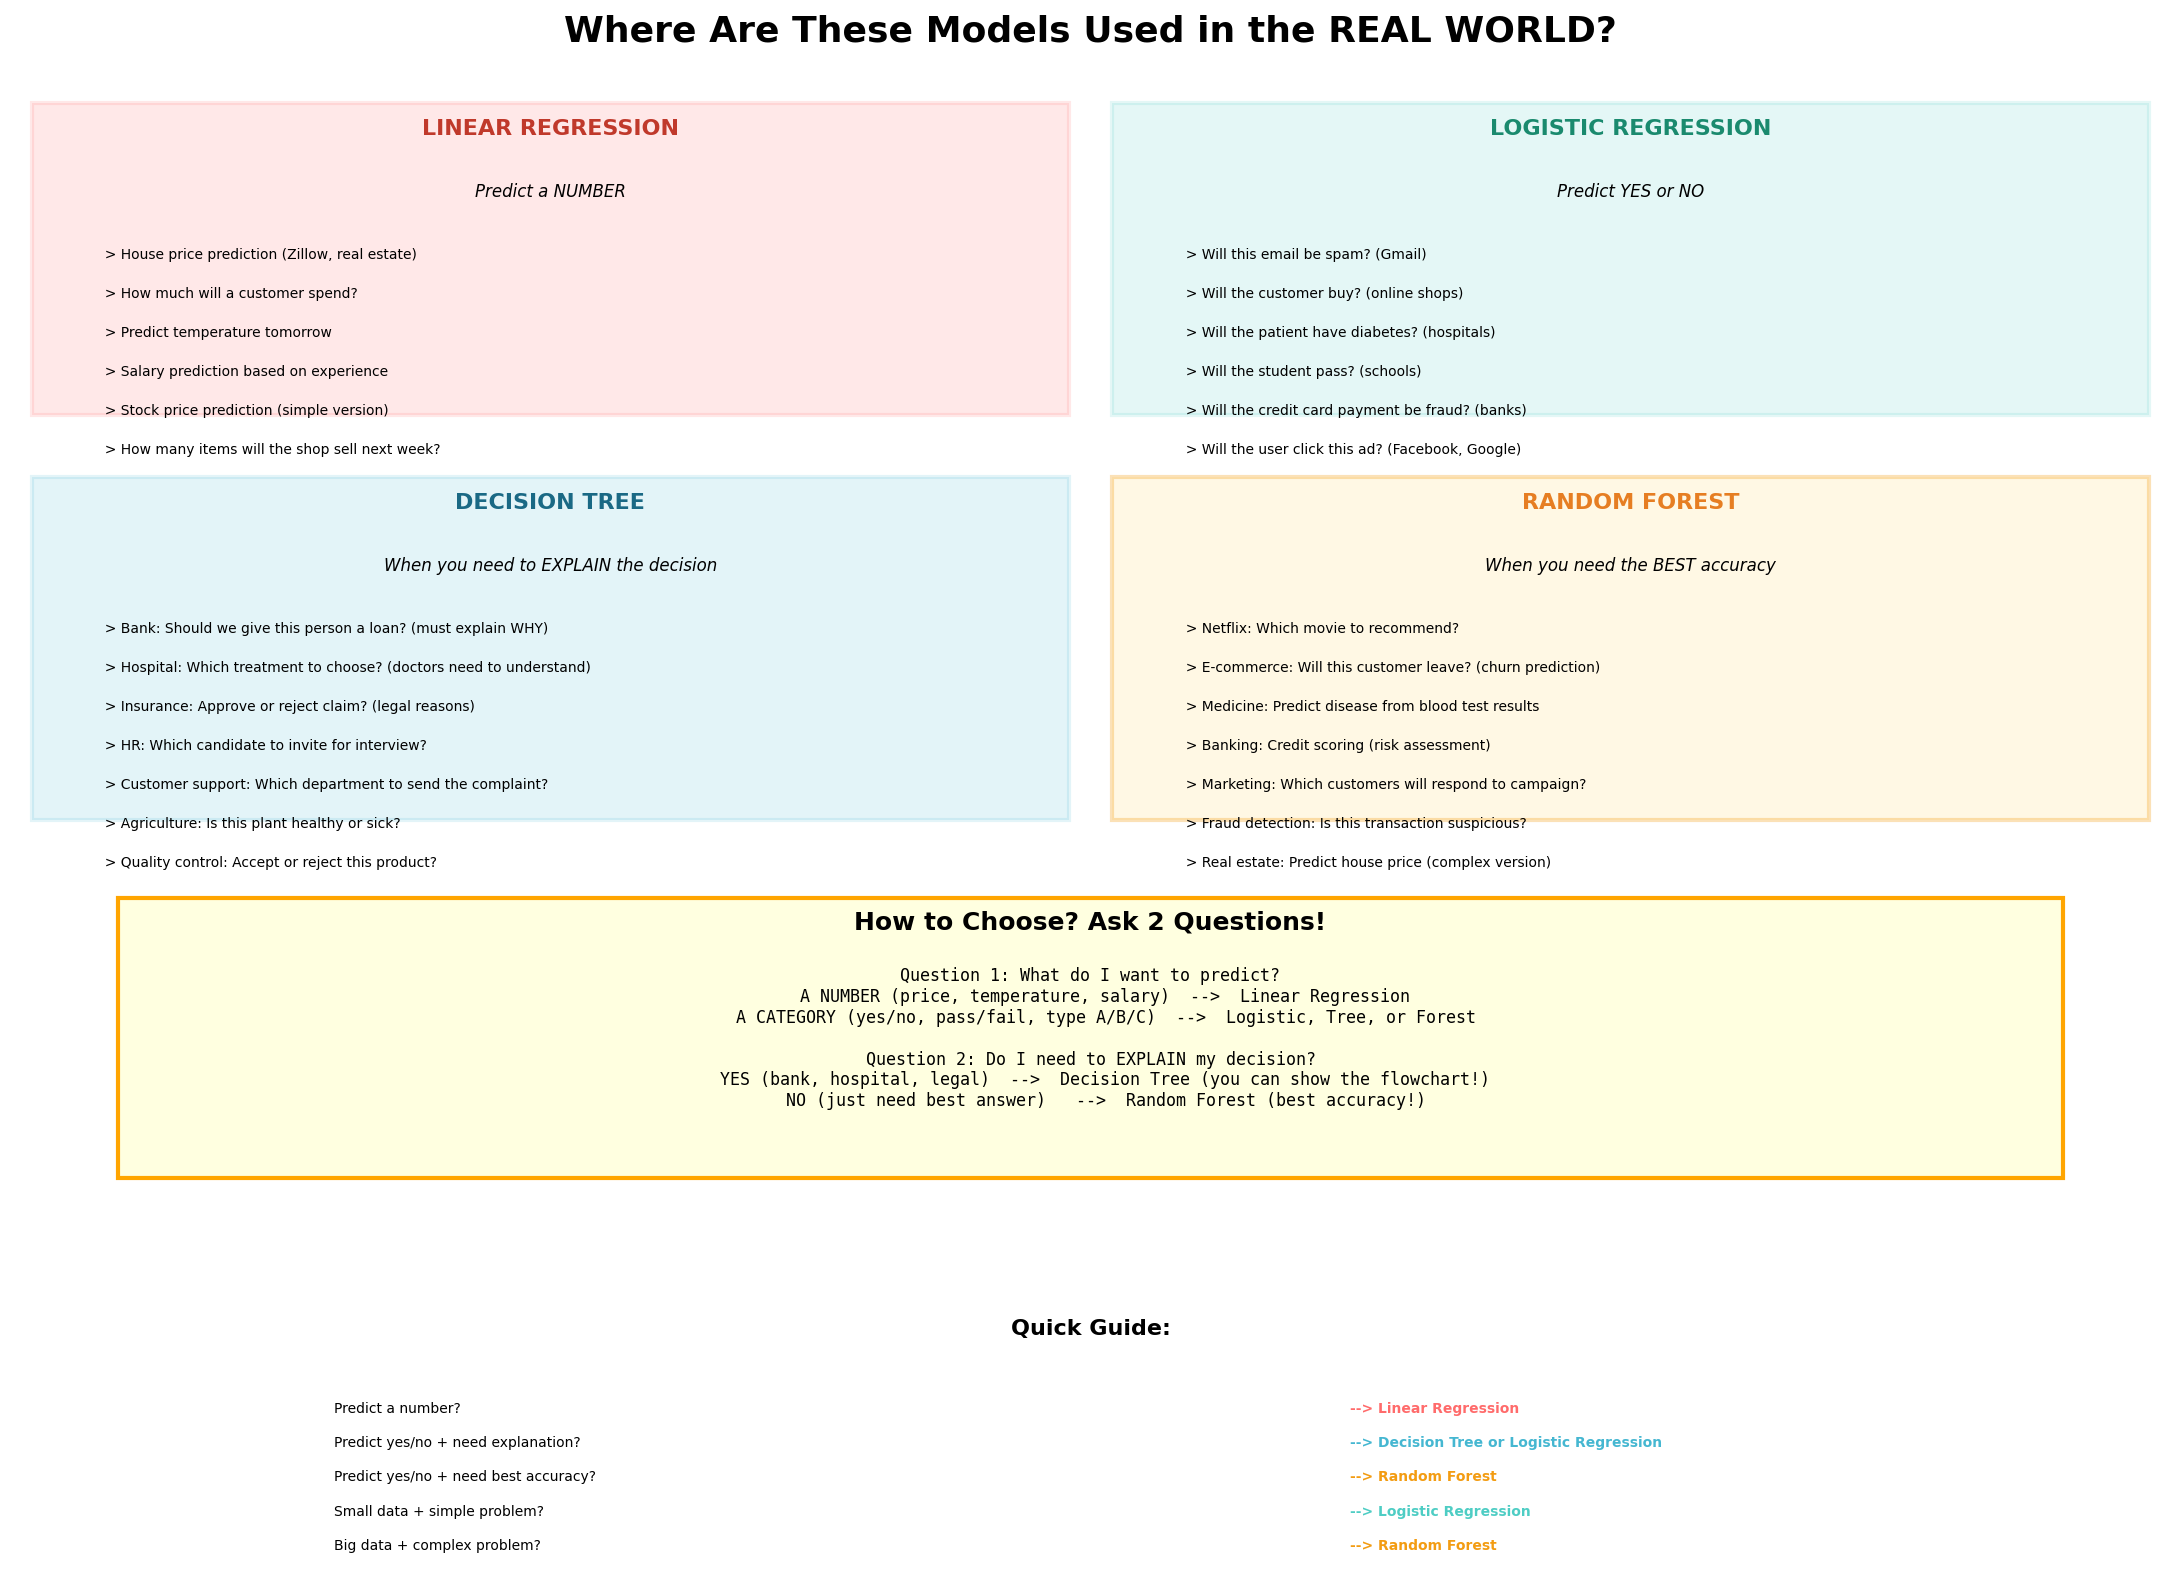

In [ ]:
# ---- VISUAL: Real World Use Cases ----

fig, ax = plt.subplots(figsize=(22, 16))
ax.axis('off')

ax.text(0.5, 0.98, 'Where Are These Models Used in the REAL WORLD?', ha='center',
        fontsize=26, fontweight='bold', transform=ax.transAxes)

# ---- LINEAR REGRESSION ----
ax.add_patch(plt.Rectangle((0.01, 0.74), 0.48, 0.20, transform=ax.transAxes,
             facecolor='#FF6B6B', alpha=0.15, edgecolor='#FF6B6B', lw=3))
ax.text(0.25, 0.92, 'LINEAR REGRESSION', ha='center', fontsize=16,
        fontweight='bold', transform=ax.transAxes, color='#c0392b')
ax.text(0.25, 0.88, 'Predict a NUMBER', ha='center', fontsize=12,
        transform=ax.transAxes, style='italic')

lr_examples = [
    'House price prediction (Zillow, real estate)',
    'How much will a customer spend?',
    'Predict temperature tomorrow',
    'Salary prediction based on experience',
    'Stock price prediction (simple version)',
    'How many items will the shop sell next week?',
]
for i, ex in enumerate(lr_examples):
    ax.text(0.04, 0.84 - i*0.025, f'  > {ex}', fontsize=10, transform=ax.transAxes)

# ---- LOGISTIC REGRESSION ----
ax.add_patch(plt.Rectangle((0.51, 0.74), 0.48, 0.20, transform=ax.transAxes,
             facecolor='#4ECDC4', alpha=0.15, edgecolor='#4ECDC4', lw=3))
ax.text(0.75, 0.92, 'LOGISTIC REGRESSION', ha='center', fontsize=16,
        fontweight='bold', transform=ax.transAxes, color='#1a8a6e')
ax.text(0.75, 0.88, 'Predict YES or NO', ha='center', fontsize=12,
        transform=ax.transAxes, style='italic')

log_examples = [
    'Will this email be spam? (Gmail)',
    'Will the customer buy? (online shops)',
    'Will the patient have diabetes? (hospitals)',
    'Will the student pass? (schools)',
    'Will the credit card payment be fraud? (banks)',
    'Will the user click this ad? (Facebook, Google)',
]
for i, ex in enumerate(log_examples):
    ax.text(0.54, 0.84 - i*0.025, f'  > {ex}', fontsize=10, transform=ax.transAxes)

# ---- DECISION TREE ----
ax.add_patch(plt.Rectangle((0.01, 0.48), 0.48, 0.22, transform=ax.transAxes,
             facecolor='#45B7D1', alpha=0.15, edgecolor='#45B7D1', lw=3))
ax.text(0.25, 0.68, 'DECISION TREE', ha='center', fontsize=16,
        fontweight='bold', transform=ax.transAxes, color='#1a6985')
ax.text(0.25, 0.64, 'When you need to EXPLAIN the decision', ha='center', fontsize=12,
        transform=ax.transAxes, style='italic')

dt_examples = [
    'Bank: Should we give this person a loan? (must explain WHY)',
    'Hospital: Which treatment to choose? (doctors need to understand)',
    'Insurance: Approve or reject claim? (legal reasons)',
    'HR: Which candidate to invite for interview?',
    'Customer support: Which department to send the complaint?',
    'Agriculture: Is this plant healthy or sick?',
    'Quality control: Accept or reject this product?',
]
for i, ex in enumerate(dt_examples):
    ax.text(0.04, 0.60 - i*0.025, f'  > {ex}', fontsize=10, transform=ax.transAxes)

# ---- RANDOM FOREST ----
ax.add_patch(plt.Rectangle((0.51, 0.48), 0.48, 0.22, transform=ax.transAxes,
             facecolor='#FFEAA7', alpha=0.3, edgecolor='#F39C12', lw=3))
ax.text(0.75, 0.68, 'RANDOM FOREST', ha='center', fontsize=16,
        fontweight='bold', transform=ax.transAxes, color='#e67e22')
ax.text(0.75, 0.64, 'When you need the BEST accuracy', ha='center', fontsize=12,
        transform=ax.transAxes, style='italic')

rf_examples = [
    'Netflix: Which movie to recommend?',
    'E-commerce: Will this customer leave? (churn prediction)',
    'Medicine: Predict disease from blood test results',
    'Banking: Credit scoring (risk assessment)',
    'Marketing: Which customers will respond to campaign?',
    'Fraud detection: Is this transaction suspicious?',
    'Real estate: Predict house price (complex version)',
]
for i, ex in enumerate(rf_examples):
    ax.text(0.54, 0.60 - i*0.025, f'  > {ex}', fontsize=10, transform=ax.transAxes)

# KEY INSIGHT
ax.add_patch(plt.Rectangle((0.05, 0.25), 0.90, 0.18, transform=ax.transAxes,
             facecolor='lightyellow', edgecolor='orange', lw=3))
ax.text(0.5, 0.41, 'How to Choose? Ask 2 Questions!', ha='center', fontsize=18,
        fontweight='bold', transform=ax.transAxes)

ax.text(0.5, 0.34,
        'Question 1: What do I want to predict?\n'
        '   A NUMBER (price, temperature, salary)  -->  Linear Regression\n'
        '   A CATEGORY (yes/no, pass/fail, type A/B/C)  -->  Logistic, Tree, or Forest\n\n'
        'Question 2: Do I need to EXPLAIN my decision?\n'
        '   YES (bank, hospital, legal)  -->  Decision Tree (you can show the flowchart!)\n'
        '   NO (just need best answer)   -->  Random Forest (best accuracy!)',
        ha='center', va='center', fontsize=12, transform=ax.transAxes, fontfamily='monospace')

# Quick guide
ax.text(0.5, 0.15, 'Quick Guide:', ha='center', fontsize=16, fontweight='bold',
        transform=ax.transAxes)
guide = [
    ('Predict a number?', 'Linear Regression', '#FF6B6B'),
    ('Predict yes/no + need explanation?', 'Decision Tree or Logistic Regression', '#45B7D1'),
    ('Predict yes/no + need best accuracy?', 'Random Forest', '#F39C12'),
    ('Small data + simple problem?', 'Logistic Regression', '#4ECDC4'),
    ('Big data + complex problem?', 'Random Forest', '#F39C12'),
]
for i, (q, a, c) in enumerate(guide):
    ax.text(0.15, 0.10 - i*0.022, q, fontsize=10, transform=ax.transAxes)
    ax.text(0.62, 0.10 - i*0.022, f'--> {a}', fontsize=10, transform=ax.transAxes,
            fontweight='bold', color=c)

plt.tight_layout()
plt.show()

---

# 9️⃣ BIG COMPARISON: All 4 Models Side by Side

---

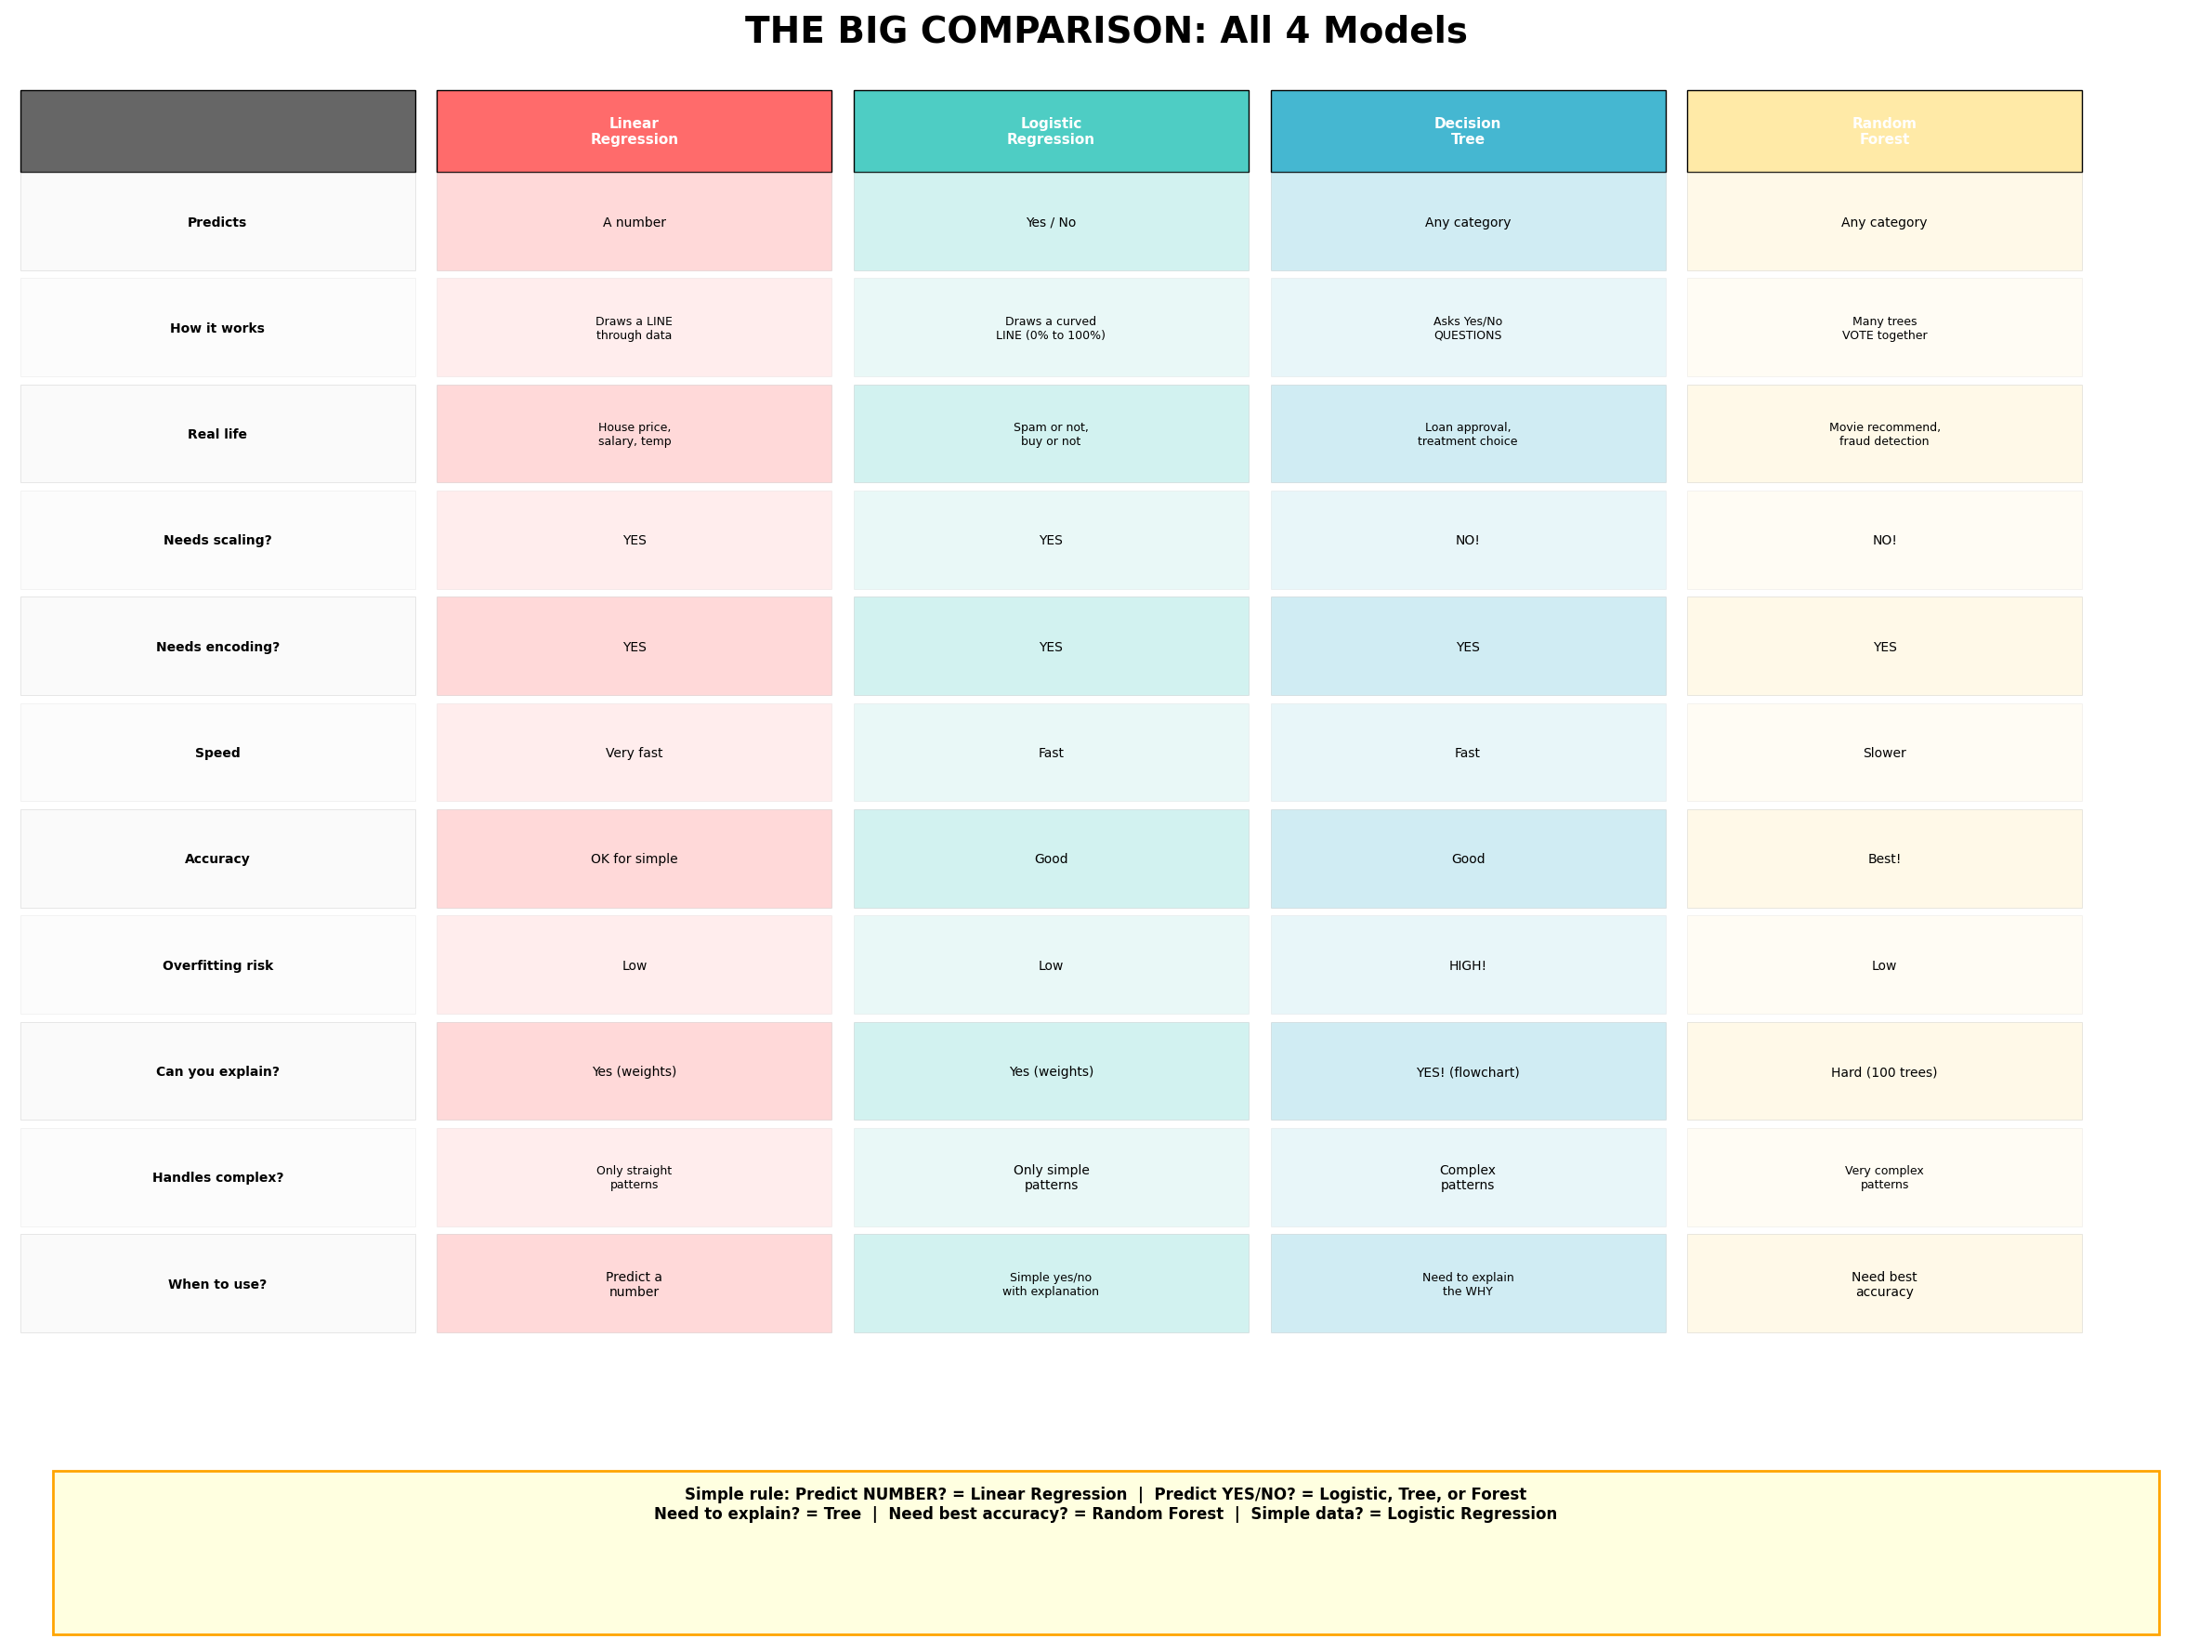

In [ ]:
# ---- VISUAL: The BIG comparison chart ----

fig, ax = plt.subplots(figsize=(24, 18))
ax.axis('off')

ax.text(0.5, 0.98, 'THE BIG COMPARISON: All 4 Models', ha='center',
        fontsize=28, fontweight='bold', transform=ax.transAxes)

# Column headers
col_headers = ['', 'Linear\nRegression', 'Logistic\nRegression', 'Decision\nTree', 'Random\nForest']
col_colors_h = ['#666', '#FF6B6B', '#4ECDC4', '#45B7D1', '#FFEAA7']
col_w = 0.19

for j, (h, c) in enumerate(zip(col_headers, col_colors_h)):
    ax.add_patch(plt.Rectangle((j*col_w + 0.005, 0.90), col_w-0.01, 0.05,
                 transform=ax.transAxes, facecolor=c, edgecolor='black', lw=1))
    ax.text(j*col_w + col_w/2, 0.925, h, ha='center', va='center', fontsize=11,
            fontweight='bold', color='white' if j > 0 else 'white', transform=ax.transAxes)

# Rows
rows_data = [
    ['Predicts', 'A number', 'Yes / No', 'Any category', 'Any category'],
    ['How it works', 'Draws a LINE\nthrough data', 'Draws a curved\nLINE (0% to 100%)', 'Asks Yes/No\nQUESTIONS', 'Many trees\nVOTE together'],
    ['Real life', 'House price,\nsalary, temp', 'Spam or not,\nbuy or not', 'Loan approval,\ntreatment choice', 'Movie recommend,\nfraud detection'],
    ['Needs scaling?', 'YES', 'YES', 'NO!', 'NO!'],
    ['Needs encoding?', 'YES', 'YES', 'YES', 'YES'],
    ['Speed', 'Very fast', 'Fast', 'Fast', 'Slower'],
    ['Accuracy', 'OK for simple', 'Good', 'Good', 'Best!'],
    ['Overfitting risk', 'Low', 'Low', 'HIGH!', 'Low'],
    ['Can you explain?', 'Yes (weights)', 'Yes (weights)', 'YES! (flowchart)', 'Hard (100 trees)'],
    ['Handles complex?', 'Only straight\npatterns', 'Only simple\npatterns', 'Complex\npatterns', 'Very complex\npatterns'],
    ['When to use?', 'Predict a\nnumber', 'Simple yes/no\nwith explanation', 'Need to explain\nthe WHY', 'Need best\naccuracy'],
]

row_h = 0.065
for i, row in enumerate(rows_data):
    for j, val in enumerate(row):
        alpha = 0.25 if i % 2 == 0 else 0.12
        fc = col_colors_h[j] if j > 0 else '#eee'
        y = 0.84 - i * row_h
        ax.add_patch(plt.Rectangle((j*col_w + 0.005, y), col_w-0.01, row_h-0.005,
                     transform=ax.transAxes, facecolor=fc, alpha=alpha,
                     edgecolor='gray', lw=0.5))
        weight = 'bold' if j == 0 else 'normal'
        fsize = 9 if len(val) > 20 else 10
        ax.text(j*col_w + col_w/2, y + row_h/2 - 0.003, val, ha='center', va='center',
                fontsize=fsize, fontweight=weight, transform=ax.transAxes)

# Bottom summary
y_bottom = 0.84 - len(rows_data) * row_h - 0.02
ax.add_patch(plt.Rectangle((0.02, y_bottom - 0.10), 0.96, 0.10,
             transform=ax.transAxes, facecolor='lightyellow', edgecolor='orange', lw=2))
ax.text(0.5, y_bottom - 0.02,
        'Simple rule: Predict NUMBER? = Linear Regression  |  Predict YES/NO? = Logistic, Tree, or Forest\n'
        'Need to explain? = Tree  |  Need best accuracy? = Random Forest  |  Simple data? = Logistic Regression',
        ha='center', va='center', fontsize=12, fontweight='bold', transform=ax.transAxes)

plt.tight_layout()
plt.show()

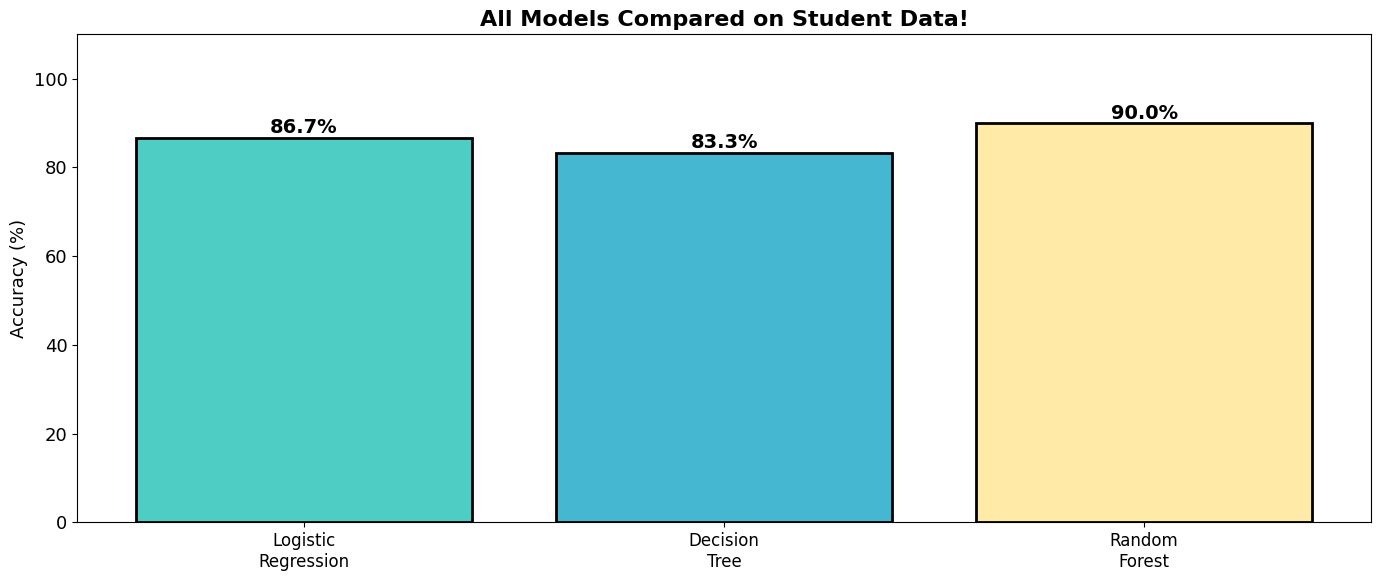

Logistic Regression: 86.7%
Decision Tree: 83.3%
Random Forest: 90.0%

Winner: Random Forest!


In [ ]:
# ---- TRAIN all 4 models and compare ----

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler

# Scale for linear models (tree models don't need it)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# Train all 4
models = {
    'Logistic\nRegression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision\nTree': DecisionTreeClassifier(max_depth=4, min_samples_leaf=10, random_state=42),
    'Random\nForest': RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42),
}

results = {}
for name, model in models.items():
    # Tree models don't need scaling, but logistic does
    if 'Logistic' in name:
        model.fit(X_train_s, y_train)
        pred = model.predict(X_test_s)
    else:
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
    results[name] = accuracy_score(y_test, pred)

# Show results
fig, ax = plt.subplots(figsize=(14, 6))
names = list(results.keys())
accs = [v * 100 for v in results.values()]
colors = ['#4ECDC4', '#45B7D1', '#FFEAA7']
bars = ax.bar(range(len(names)), accs, color=colors, edgecolor='black', lw=2)
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, fontsize=12)
ax.set_ylim(0, 110)
ax.set_ylabel('Accuracy (%)')
ax.set_title('All Models Compared on Student Data!', fontsize=16, fontweight='bold')

for bar, a in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{a:.1f}%', ha='center', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

for name, acc in results.items():
    print(f'{name.replace(chr(10), " ")}: {acc:.1%}')
print(f'\nWinner: {max(results, key=results.get).replace(chr(10), " ")}!')

---

# 🔟 Why You Do NOT Need to Know the Math

---

## Students always ask: "Do I need to understand all the math?"

## Short answer: NO. Here is why.

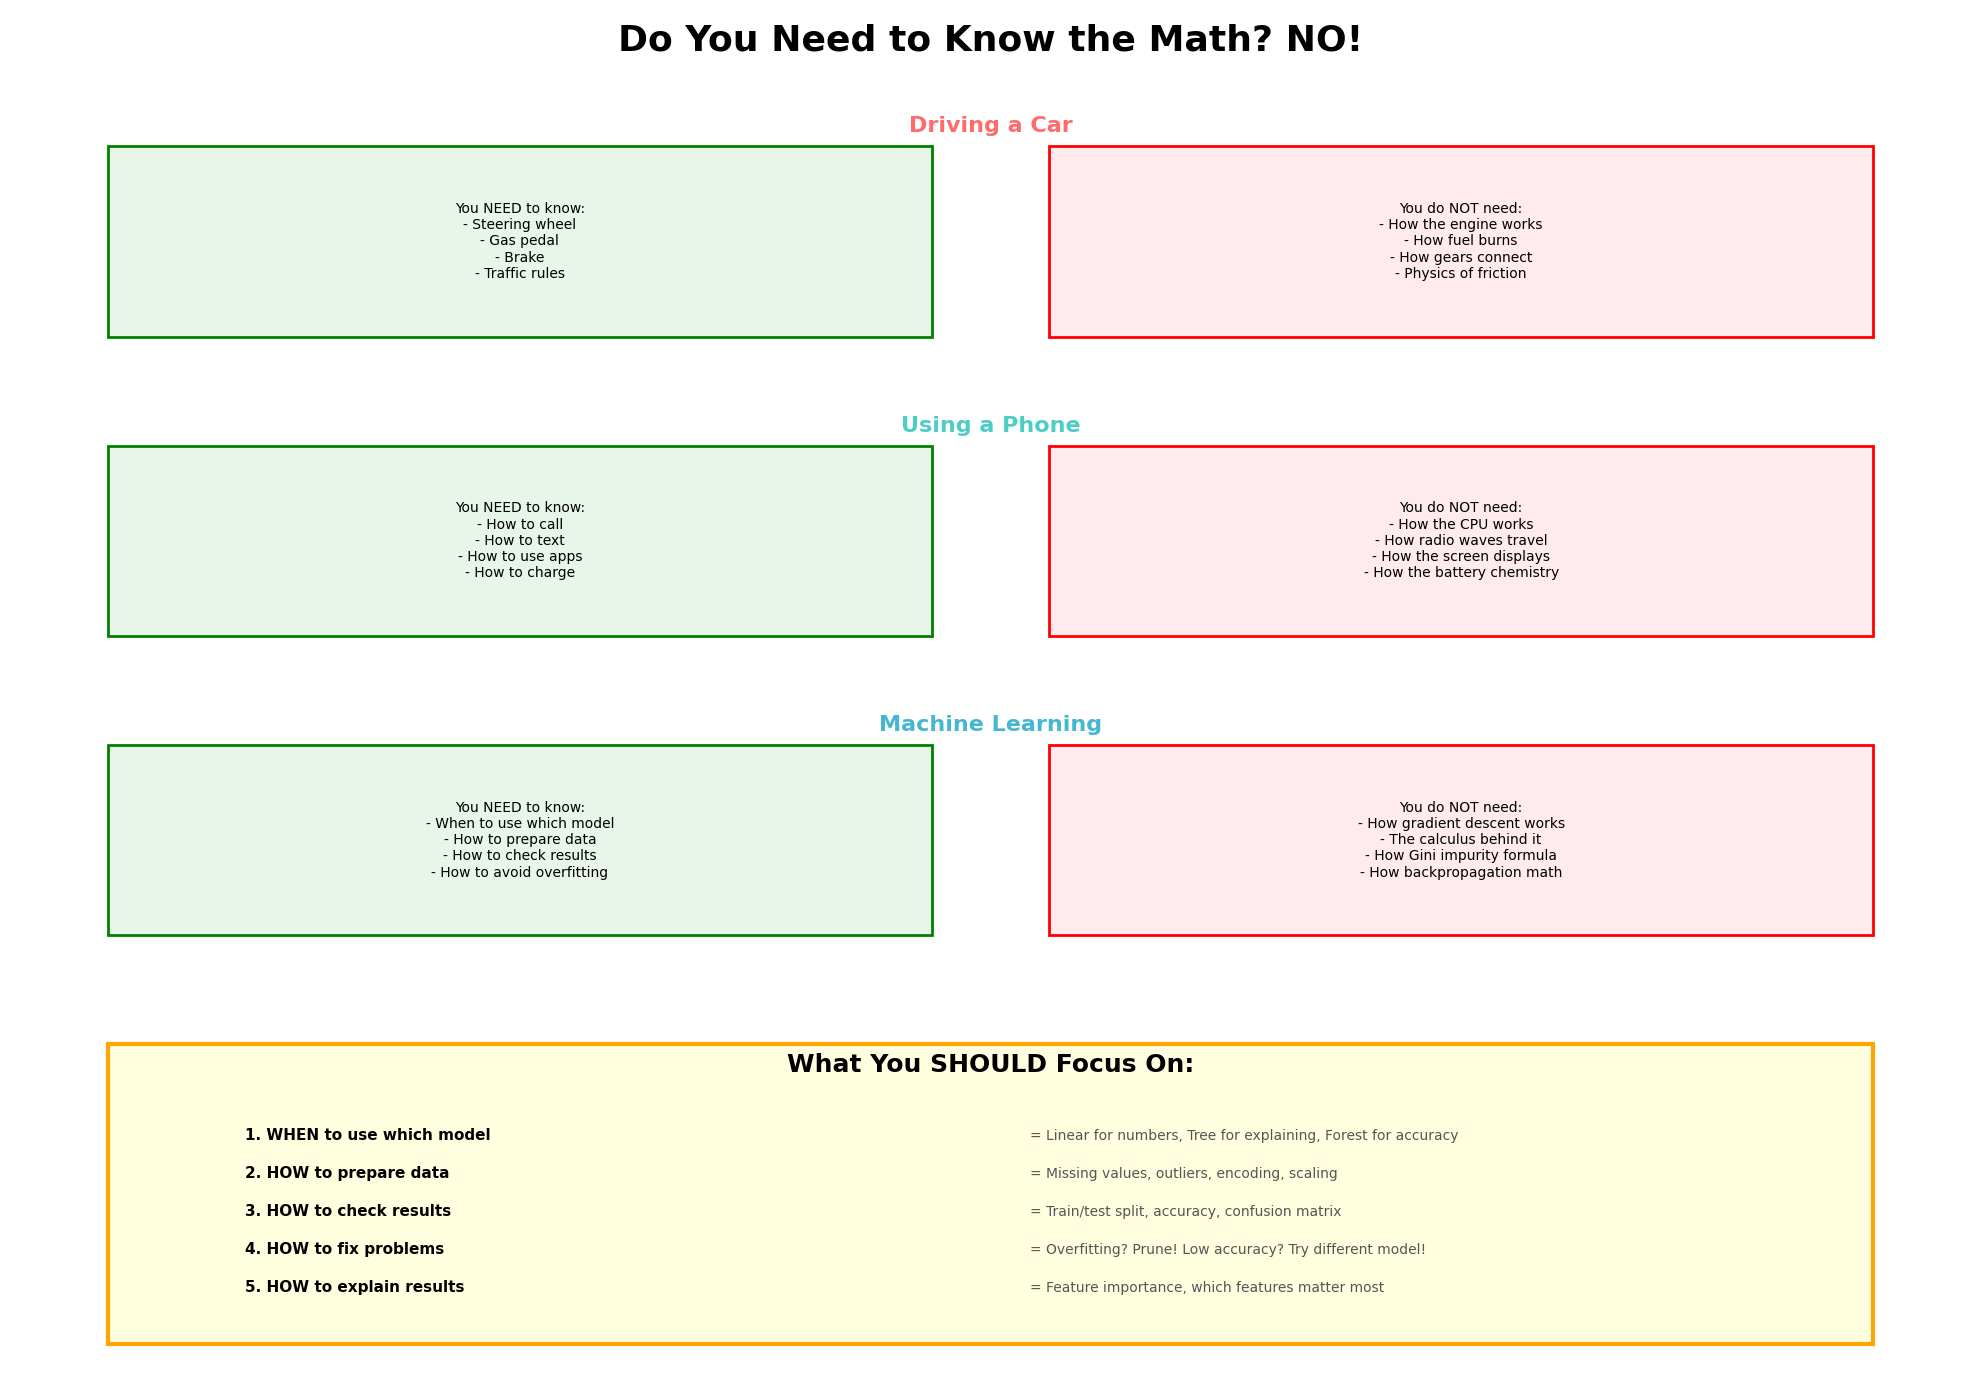

In [ ]:
# ---- VISUAL: You don't need to know how the engine works to drive a car ----

fig, ax = plt.subplots(figsize=(20, 14))
ax.axis('off')

ax.text(0.5, 0.97, 'Do You Need to Know the Math? NO!', ha='center',
        fontsize=26, fontweight='bold', transform=ax.transAxes)

# Analogy boxes
analogies = [
    {'title': 'Driving a Car', 'left': 'You NEED to know:\n- Steering wheel\n- Gas pedal\n- Brake\n- Traffic rules',
     'right': 'You do NOT need:\n- How the engine works\n- How fuel burns\n- How gears connect\n- Physics of friction',
     'y': 0.78, 'color': '#FF6B6B'},
    {'title': 'Using a Phone', 'left': 'You NEED to know:\n- How to call\n- How to text\n- How to use apps\n- How to charge',
     'right': 'You do NOT need:\n- How the CPU works\n- How radio waves travel\n- How the screen displays\n- How the battery chemistry',
     'y': 0.56, 'color': '#4ECDC4'},
    {'title': 'Machine Learning', 'left': 'You NEED to know:\n- When to use which model\n- How to prepare data\n- How to check results\n- How to avoid overfitting',
     'right': 'You do NOT need:\n- How gradient descent works\n- The calculus behind it\n- How Gini impurity formula\n- How backpropagation math',
     'y': 0.34, 'color': '#45B7D1'},
]

for a in analogies:
    ax.text(0.5, a['y'] + 0.13, a['title'], ha='center', fontsize=16,
            fontweight='bold', transform=ax.transAxes, color=a['color'])

    ax.add_patch(plt.Rectangle((0.05, a['y'] - 0.02), 0.42, 0.14, transform=ax.transAxes,
                 facecolor='#E8F5E9', edgecolor='green', lw=2))
    ax.text(0.26, a['y'] + 0.05, a['left'], ha='center', va='center', fontsize=10,
            transform=ax.transAxes)

    ax.add_patch(plt.Rectangle((0.53, a['y'] - 0.02), 0.42, 0.14, transform=ax.transAxes,
                 facecolor='#FFEBEE', edgecolor='red', lw=2))
    ax.text(0.74, a['y'] + 0.05, a['right'], ha='center', va='center', fontsize=10,
            transform=ax.transAxes)

# Key messages
ax.add_patch(plt.Rectangle((0.05, 0.02), 0.90, 0.22, transform=ax.transAxes,
             facecolor='lightyellow', edgecolor='orange', lw=3))

ax.text(0.5, 0.22, 'What You SHOULD Focus On:', ha='center', fontsize=18,
        fontweight='bold', transform=ax.transAxes)

focus_items = [
    ('1. WHEN to use which model', 'Linear for numbers, Tree for explaining, Forest for accuracy'),
    ('2. HOW to prepare data', 'Missing values, outliers, encoding, scaling'),
    ('3. HOW to check results', 'Train/test split, accuracy, confusion matrix'),
    ('4. HOW to fix problems', 'Overfitting? Prune! Low accuracy? Try different model!'),
    ('5. HOW to explain results', 'Feature importance, which features matter most'),
]

for i, (left, right) in enumerate(focus_items):
    ax.text(0.12, 0.17 - i*0.028, left, fontsize=11, fontweight='bold', transform=ax.transAxes)
    ax.text(0.52, 0.17 - i*0.028, f'= {right}', fontsize=10, transform=ax.transAxes, color='#555')

plt.tight_layout()
plt.show()

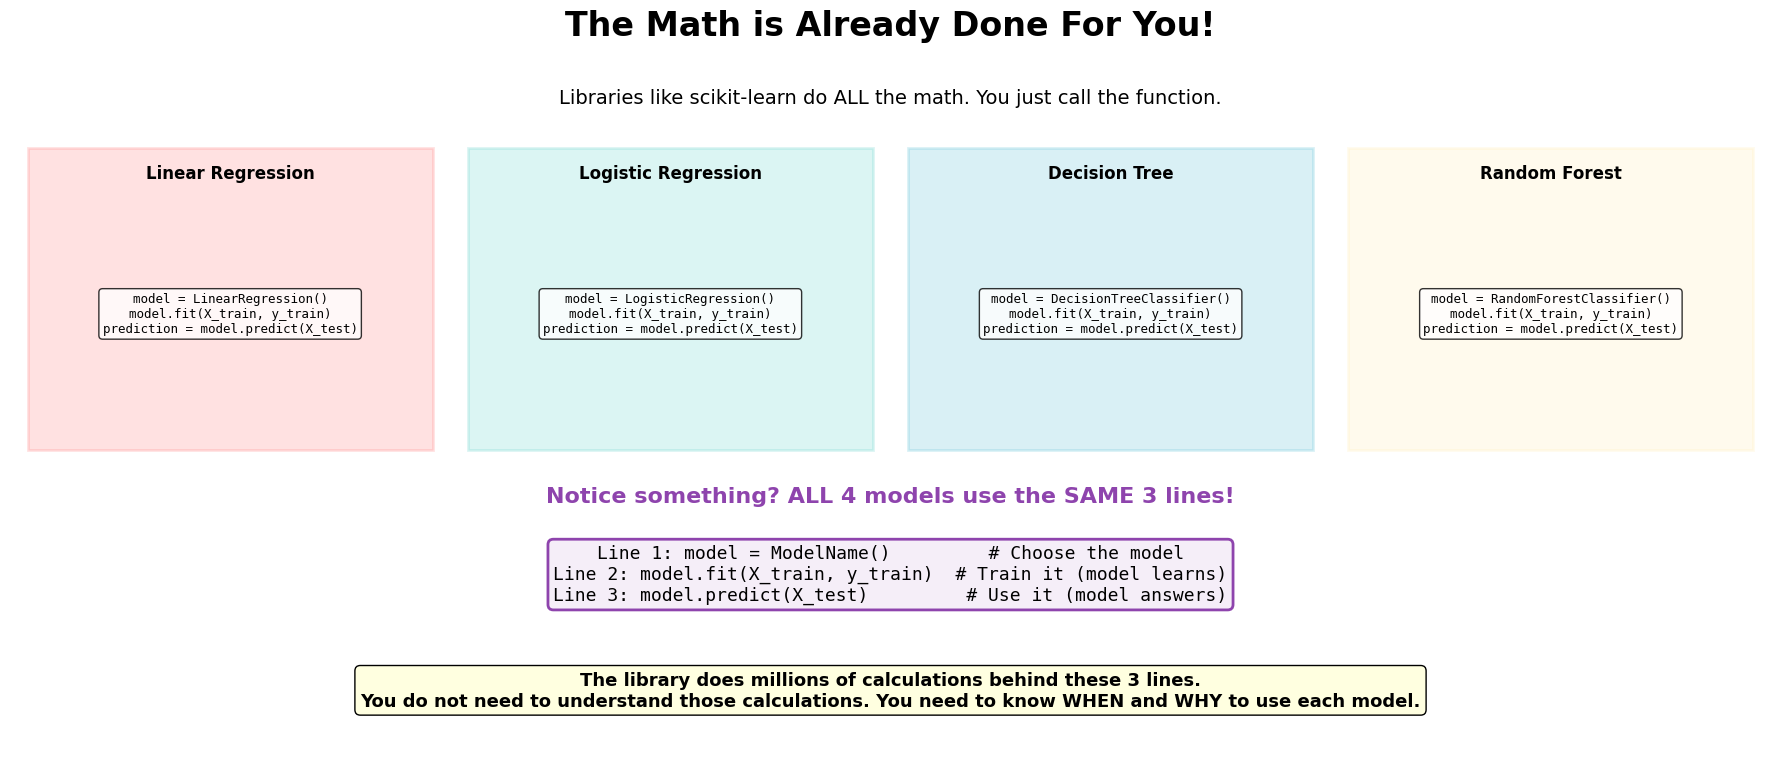

In [ ]:
# ---- VISUAL: What DOES matter vs What does NOT ----

fig, ax = plt.subplots(figsize=(18, 8))
ax.axis('off')

ax.text(0.5, 0.97, 'The Math is Already Done For You!', ha='center',
        fontsize=24, fontweight='bold', transform=ax.transAxes)

ax.text(0.5, 0.88, 'Libraries like scikit-learn do ALL the math. You just call the function.',
        ha='center', fontsize=14, transform=ax.transAxes)

# Show the simple code
code_examples = [
    ('Linear Regression', 'model = LinearRegression()\nmodel.fit(X_train, y_train)\nprediction = model.predict(X_test)', '#FF6B6B'),
    ('Logistic Regression', 'model = LogisticRegression()\nmodel.fit(X_train, y_train)\nprediction = model.predict(X_test)', '#4ECDC4'),
    ('Decision Tree', 'model = DecisionTreeClassifier()\nmodel.fit(X_train, y_train)\nprediction = model.predict(X_test)', '#45B7D1'),
    ('Random Forest', 'model = RandomForestClassifier()\nmodel.fit(X_train, y_train)\nprediction = model.predict(X_test)', '#FFEAA7'),
]

for i, (name, code, color) in enumerate(code_examples):
    x = 0.01 + i * 0.25
    ax.add_patch(plt.Rectangle((x, 0.42), 0.23, 0.40, transform=ax.transAxes,
                 facecolor=color, alpha=0.2, edgecolor=color, lw=2))
    ax.text(x + 0.115, 0.78, name, ha='center', fontsize=12, fontweight='bold',
            transform=ax.transAxes)
    ax.text(x + 0.115, 0.60, code, ha='center', va='center', fontsize=9,
            transform=ax.transAxes, fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.text(0.5, 0.35, 'Notice something? ALL 4 models use the SAME 3 lines!', ha='center',
        fontsize=16, fontweight='bold', transform=ax.transAxes, color='#8e44ad')

ax.text(0.5, 0.22,
        'Line 1: model = ModelName()         # Choose the model\n'
        'Line 2: model.fit(X_train, y_train)  # Train it (model learns)\n'
        'Line 3: model.predict(X_test)         # Use it (model answers)',
        ha='center', fontsize=13, transform=ax.transAxes, fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='#F5EEF8', edgecolor='#8e44ad', lw=2))

ax.text(0.5, 0.08, 'The library does millions of calculations behind these 3 lines.\n'
        'You do not need to understand those calculations. You need to know WHEN and WHY to use each model.',
        ha='center', fontsize=13, fontweight='bold', transform=ax.transAxes,
        bbox=dict(boxstyle='round', facecolor='lightyellow'))

plt.tight_layout()
plt.show()

---

# 1️⃣1️⃣ Many Real Examples for Students

---

## Here are MANY examples you can show to your students, organized by industry.

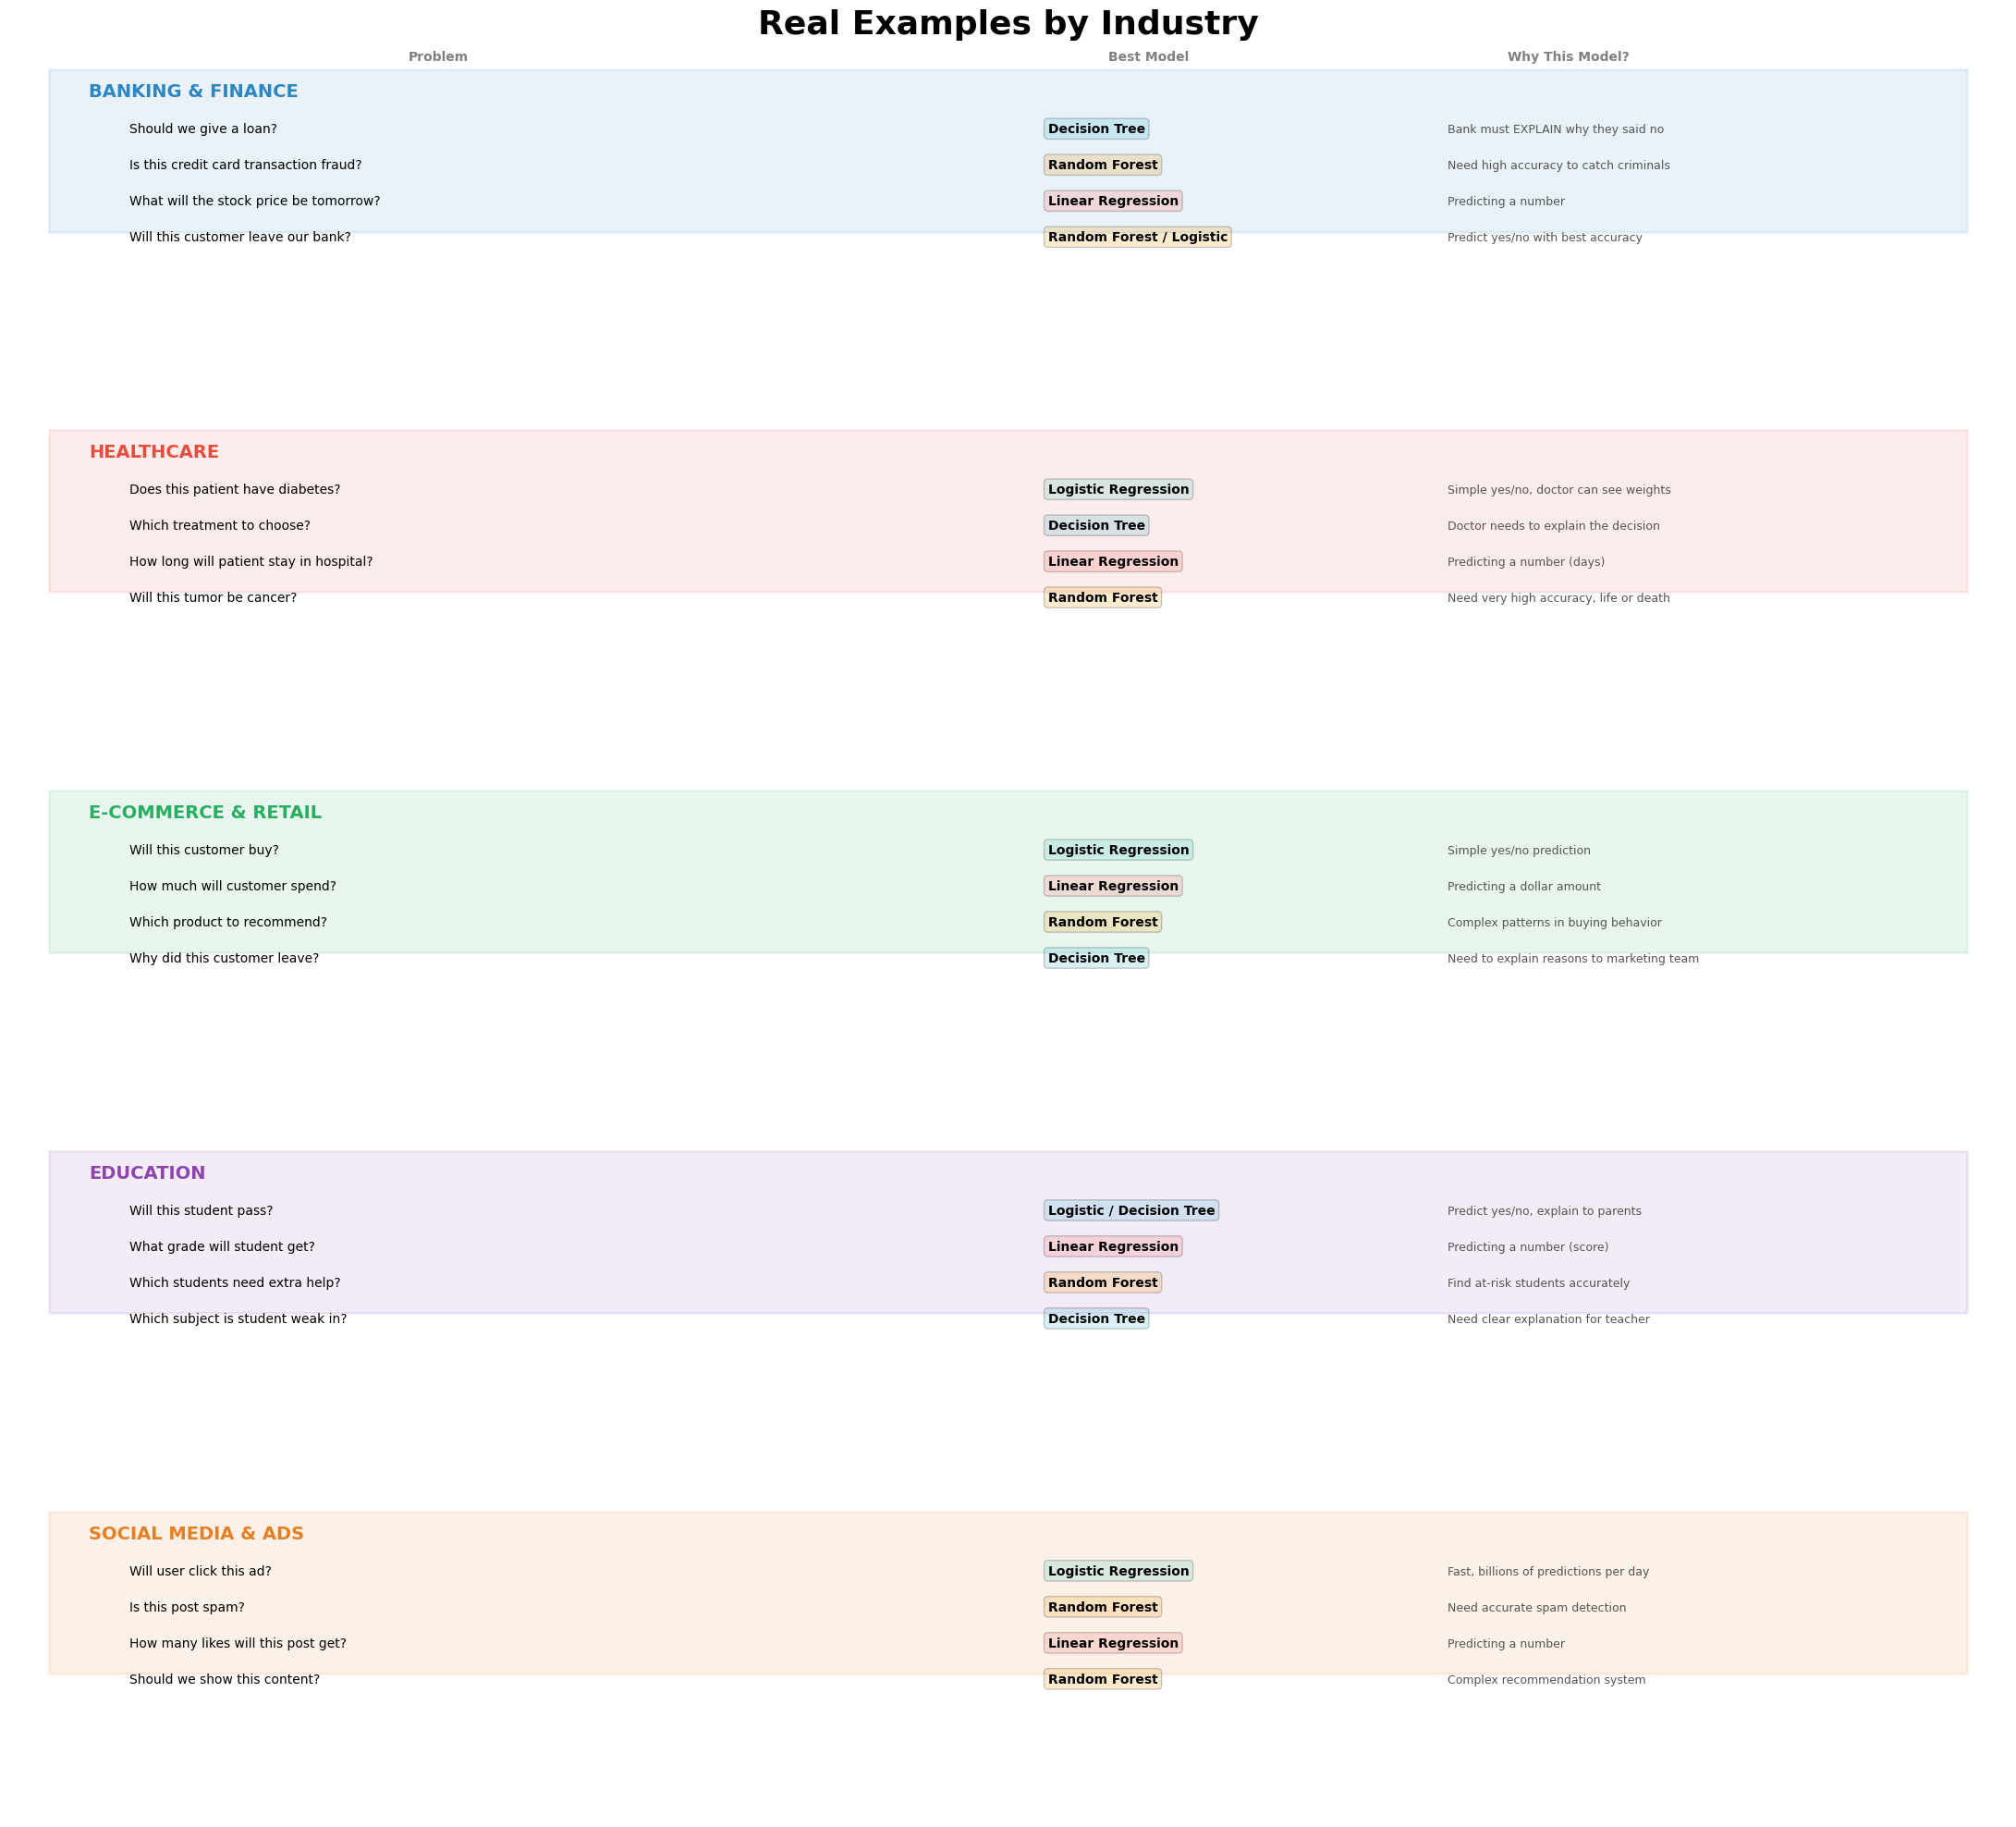

In [ ]:
# ---- VISUAL: Examples by Industry ----

fig, ax = plt.subplots(figsize=(22, 20))
ax.axis('off')

ax.text(0.5, 0.99, 'Real Examples by Industry', ha='center',
        fontsize=26, fontweight='bold', transform=ax.transAxes)

industries = [
    {'name': 'BANKING & FINANCE', 'color': '#2E86C1', 'y': 0.88, 'examples': [
        ('Should we give a loan?', 'Decision Tree', 'Bank must EXPLAIN why they said no'),
        ('Is this credit card transaction fraud?', 'Random Forest', 'Need high accuracy to catch criminals'),
        ('What will the stock price be tomorrow?', 'Linear Regression', 'Predicting a number'),
        ('Will this customer leave our bank?', 'Random Forest / Logistic', 'Predict yes/no with best accuracy'),
    ]},
    {'name': 'HEALTHCARE', 'color': '#E74C3C', 'y': 0.68, 'examples': [
        ('Does this patient have diabetes?', 'Logistic Regression', 'Simple yes/no, doctor can see weights'),
        ('Which treatment to choose?', 'Decision Tree', 'Doctor needs to explain the decision'),
        ('How long will patient stay in hospital?', 'Linear Regression', 'Predicting a number (days)'),
        ('Will this tumor be cancer?', 'Random Forest', 'Need very high accuracy, life or death'),
    ]},
    {'name': 'E-COMMERCE & RETAIL', 'color': '#27AE60', 'y': 0.48, 'examples': [
        ('Will this customer buy?', 'Logistic Regression', 'Simple yes/no prediction'),
        ('How much will customer spend?', 'Linear Regression', 'Predicting a dollar amount'),
        ('Which product to recommend?', 'Random Forest', 'Complex patterns in buying behavior'),
        ('Why did this customer leave?', 'Decision Tree', 'Need to explain reasons to marketing team'),
    ]},
    {'name': 'EDUCATION', 'color': '#8E44AD', 'y': 0.28, 'examples': [
        ('Will this student pass?', 'Logistic / Decision Tree', 'Predict yes/no, explain to parents'),
        ('What grade will student get?', 'Linear Regression', 'Predicting a number (score)'),
        ('Which students need extra help?', 'Random Forest', 'Find at-risk students accurately'),
        ('Which subject is student weak in?', 'Decision Tree', 'Need clear explanation for teacher'),
    ]},
    {'name': 'SOCIAL MEDIA & ADS', 'color': '#E67E22', 'y': 0.08, 'examples': [
        ('Will user click this ad?', 'Logistic Regression', 'Fast, billions of predictions per day'),
        ('Is this post spam?', 'Random Forest', 'Need accurate spam detection'),
        ('How many likes will this post get?', 'Linear Regression', 'Predicting a number'),
        ('Should we show this content?', 'Random Forest', 'Complex recommendation system'),
    ]},
]

for ind in industries:
    # Industry header
    ax.add_patch(plt.Rectangle((0.02, ind['y']), 0.96, 0.09, transform=ax.transAxes,
                 facecolor=ind['color'], alpha=0.1, edgecolor=ind['color'], lw=2))
    ax.text(0.04, ind['y'] + 0.075, ind['name'], fontsize=14, fontweight='bold',
            transform=ax.transAxes, color=ind['color'])

    # Column headers for first industry only
    if ind == industries[0]:
        ax.text(0.20, ind['y'] + 0.095, 'Problem', fontsize=10, fontweight='bold',
                transform=ax.transAxes, color='gray')
        ax.text(0.55, ind['y'] + 0.095, 'Best Model', fontsize=10, fontweight='bold',
                transform=ax.transAxes, color='gray')
        ax.text(0.75, ind['y'] + 0.095, 'Why This Model?', fontsize=10, fontweight='bold',
                transform=ax.transAxes, color='gray')

    for i, (problem, model, why) in enumerate(ind['examples']):
        y = ind['y'] + 0.055 - i * 0.02
        ax.text(0.06, y, f'{problem}', fontsize=10, transform=ax.transAxes)

        # Color code the model
        model_colors = {'Linear Regression': '#FF6B6B', 'Logistic Regression': '#4ECDC4',
                       'Decision Tree': '#45B7D1', 'Random Forest': '#F39C12',
                       'Logistic / Decision Tree': '#45B7D1', 'Random Forest / Logistic': '#F39C12',
                       'Logistic': '#4ECDC4'}
        mc = model_colors.get(model, '#999')
        ax.text(0.52, y, model, fontsize=10, fontweight='bold', transform=ax.transAxes,
                bbox=dict(boxstyle='round', facecolor=mc, alpha=0.2))
        ax.text(0.72, y, why, fontsize=9, transform=ax.transAxes, color='#555')

plt.tight_layout()
plt.show()

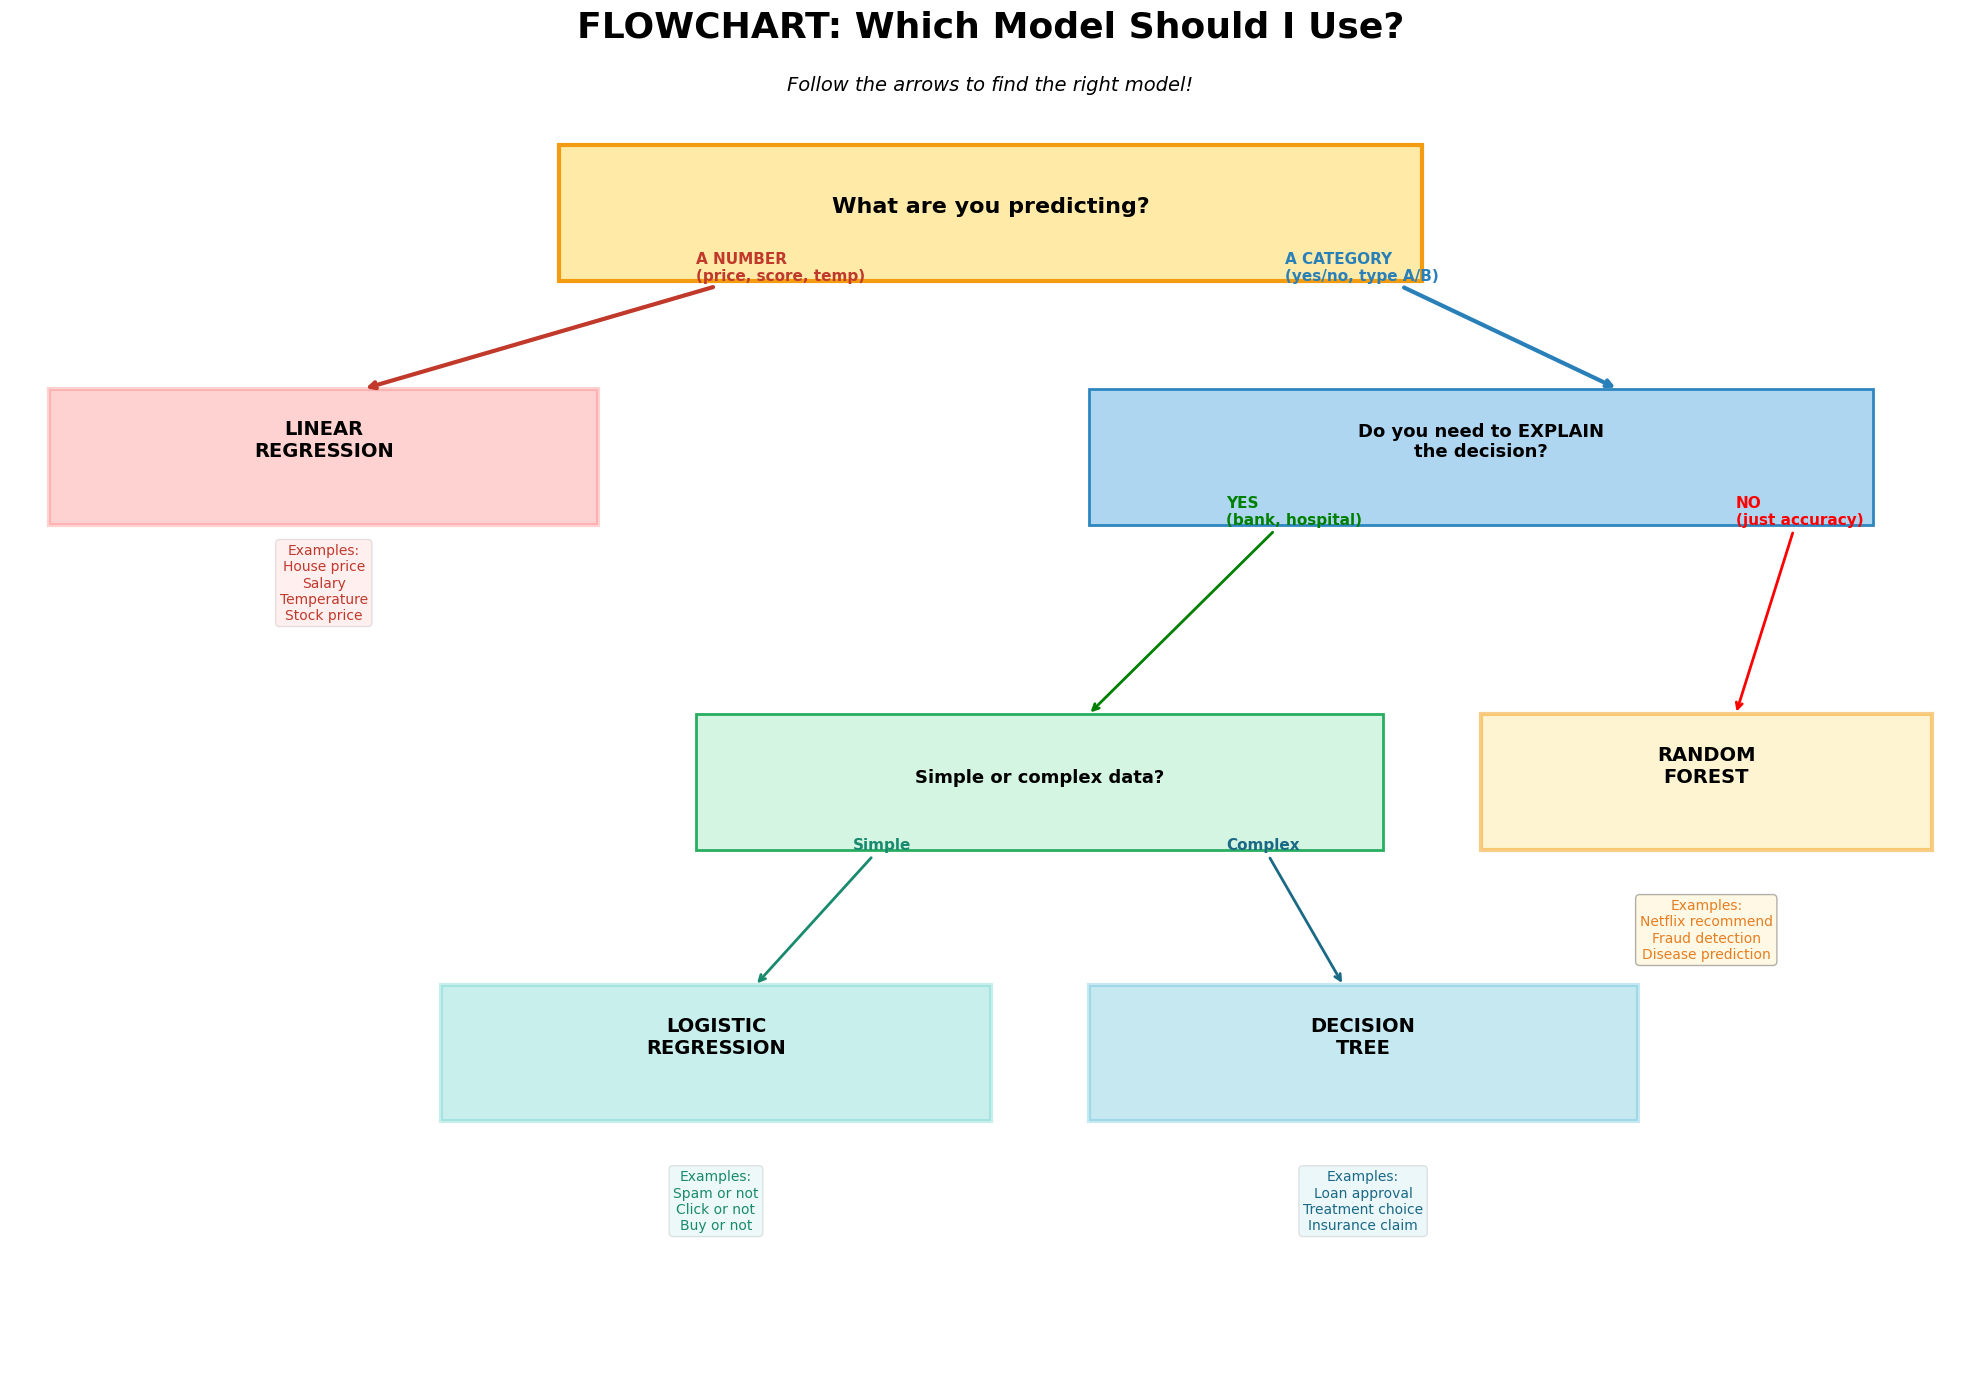

In [ ]:
# ---- VISUAL: Decision Flowchart - Which Model to Use? ----

fig, ax = plt.subplots(figsize=(20, 14))
ax.axis('off')

ax.text(0.5, 0.98, 'FLOWCHART: Which Model Should I Use?', ha='center',
        fontsize=26, fontweight='bold', transform=ax.transAxes)
ax.text(0.5, 0.94, 'Follow the arrows to find the right model!', ha='center',
        fontsize=14, transform=ax.transAxes, style='italic')

# Q1: What are you predicting?
ax.add_patch(plt.Rectangle((0.28, 0.80), 0.44, 0.10, transform=ax.transAxes,
             facecolor='#FFEAA7', edgecolor='#F39C12', lw=3))
ax.text(0.50, 0.85, 'What are you predicting?', ha='center', fontsize=16,
        fontweight='bold', transform=ax.transAxes)

# A NUMBER
ax.annotate('A NUMBER\n(price, score, temp)', xy=(0.18, 0.72), xytext=(0.35, 0.80),
            transform=ax.transAxes, fontsize=11, fontweight='bold', color='#c0392b',
            arrowprops=dict(arrowstyle='->', lw=3, color='#c0392b'))

ax.add_patch(plt.Rectangle((0.02, 0.62), 0.28, 0.10, transform=ax.transAxes,
             facecolor='#FF6B6B', alpha=0.3, edgecolor='#FF6B6B', lw=3))
ax.text(0.16, 0.67, 'LINEAR\nREGRESSION', ha='center', fontsize=14,
        fontweight='bold', transform=ax.transAxes)

# A CATEGORY
ax.annotate('A CATEGORY\n(yes/no, type A/B)', xy=(0.82, 0.72), xytext=(0.65, 0.80),
            transform=ax.transAxes, fontsize=11, fontweight='bold', color='#2980b9',
            arrowprops=dict(arrowstyle='->', lw=3, color='#2980b9'))

# Q2: Do you need to explain?
ax.add_patch(plt.Rectangle((0.55, 0.62), 0.40, 0.10, transform=ax.transAxes,
             facecolor='#AED6F1', edgecolor='#2E86C1', lw=2))
ax.text(0.75, 0.67, 'Do you need to EXPLAIN\nthe decision?', ha='center', fontsize=13,
        fontweight='bold', transform=ax.transAxes)

# YES: explain
ax.annotate('YES\n(bank, hospital)', xy=(0.55, 0.48), xytext=(0.62, 0.62),
            transform=ax.transAxes, fontsize=11, fontweight='bold', color='green',
            arrowprops=dict(arrowstyle='->', lw=2, color='green'))

# Q3: Simple or complex data?
ax.add_patch(plt.Rectangle((0.35, 0.38), 0.35, 0.10, transform=ax.transAxes,
             facecolor='#D5F5E3', edgecolor='#27AE60', lw=2))
ax.text(0.525, 0.43, 'Simple or complex data?', ha='center', fontsize=13,
        fontweight='bold', transform=ax.transAxes)

# Simple -> Logistic
ax.annotate('Simple', xy=(0.38, 0.28), xytext=(0.43, 0.38),
            transform=ax.transAxes, fontsize=11, fontweight='bold', color='#1a8a6e',
            arrowprops=dict(arrowstyle='->', lw=2, color='#1a8a6e'))
ax.add_patch(plt.Rectangle((0.22, 0.18), 0.28, 0.10, transform=ax.transAxes,
             facecolor='#4ECDC4', alpha=0.3, edgecolor='#4ECDC4', lw=3))
ax.text(0.36, 0.23, 'LOGISTIC\nREGRESSION', ha='center', fontsize=14,
        fontweight='bold', transform=ax.transAxes)

# Complex -> Decision Tree
ax.annotate('Complex', xy=(0.68, 0.28), xytext=(0.62, 0.38),
            transform=ax.transAxes, fontsize=11, fontweight='bold', color='#1a6985',
            arrowprops=dict(arrowstyle='->', lw=2, color='#1a6985'))
ax.add_patch(plt.Rectangle((0.55, 0.18), 0.28, 0.10, transform=ax.transAxes,
             facecolor='#45B7D1', alpha=0.3, edgecolor='#45B7D1', lw=3))
ax.text(0.69, 0.23, 'DECISION\nTREE', ha='center', fontsize=14,
        fontweight='bold', transform=ax.transAxes)

# NO: don't need to explain
ax.annotate('NO\n(just accuracy)', xy=(0.88, 0.48), xytext=(0.88, 0.62),
            transform=ax.transAxes, fontsize=11, fontweight='bold', color='red',
            arrowprops=dict(arrowstyle='->', lw=2, color='red'))

ax.add_patch(plt.Rectangle((0.75, 0.38), 0.23, 0.10, transform=ax.transAxes,
             facecolor='#FFEAA7', alpha=0.5, edgecolor='#F39C12', lw=3))
ax.text(0.865, 0.43, 'RANDOM\nFOREST', ha='center', fontsize=14,
        fontweight='bold', transform=ax.transAxes)

# Examples under each
ax.text(0.16, 0.55, 'Examples:\nHouse price\nSalary\nTemperature\nStock price',
        ha='center', fontsize=10, transform=ax.transAxes, color='#c0392b',
        bbox=dict(boxstyle='round', facecolor='#FF6B6B', alpha=0.1))

ax.text(0.36, 0.10, 'Examples:\nSpam or not\nClick or not\nBuy or not',
        ha='center', fontsize=10, transform=ax.transAxes, color='#1a8a6e',
        bbox=dict(boxstyle='round', facecolor='#4ECDC4', alpha=0.1))

ax.text(0.69, 0.10, 'Examples:\nLoan approval\nTreatment choice\nInsurance claim',
        ha='center', fontsize=10, transform=ax.transAxes, color='#1a6985',
        bbox=dict(boxstyle='round', facecolor='#45B7D1', alpha=0.1))

ax.text(0.865, 0.30, 'Examples:\nNetflix recommend\nFraud detection\nDisease prediction',
        ha='center', fontsize=10, transform=ax.transAxes, color='#e67e22',
        bbox=dict(boxstyle='round', facecolor='#FFEAA7', alpha=0.3))

plt.tight_layout()
plt.show()

EXAMPLE 1: Predict house price (Linear Regression)
New house: 3 rooms, 90 sqm
Predicted price: $197,018


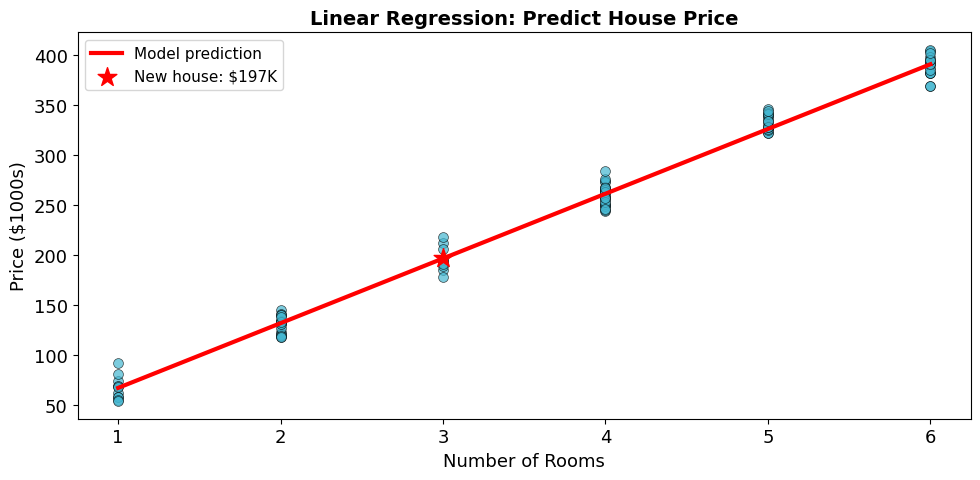

In [ ]:
# ---- REAL EXAMPLE: Build a model for each scenario ----

print('=' * 60)
print('EXAMPLE 1: Predict house price (Linear Regression)')
print('=' * 60)

# Simple house data
np.random.seed(42)
rooms = np.random.randint(1, 7, 100)
size = rooms * 30 + np.random.normal(0, 10, 100)
price = rooms * 50000 + size * 500 + np.random.normal(0, 10000, 100)

house_X = pd.DataFrame({'Rooms': rooms, 'Size_sqm': size})
house_y = price

from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(house_X, house_y)

# Predict for a new house
new_house = pd.DataFrame({'Rooms': [3], 'Size_sqm': [90]})
pred_price = lr.predict(new_house)[0]
print(f'New house: 3 rooms, 90 sqm')
print(f'Predicted price: ${pred_price:,.0f}')

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(rooms, price/1000, c='#45B7D1', s=50, edgecolors='black', lw=0.5, alpha=0.7)
rooms_range = np.array([[i, i*30] for i in range(1, 7)])
pred_range = lr.predict(rooms_range) / 1000
ax.plot(range(1, 7), pred_range, color='red', lw=3, label='Model prediction')
ax.scatter([3], [pred_price/1000], c='red', s=200, marker='*', zorder=5, label=f'New house: ${pred_price/1000:.0f}K')
ax.set_xlabel('Number of Rooms')
ax.set_ylabel('Price ($1000s)')
ax.set_title('Linear Regression: Predict House Price', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
print('=' * 60)
print('EXAMPLE 2: Is this email spam? (Logistic Regression)')
print('=' * 60)

np.random.seed(42)
n = 200
word_count = np.random.randint(5, 500, n)
links = np.random.randint(0, 20, n)
caps_pct = np.random.uniform(0, 80, n)
has_attachment = np.random.choice([0, 1], n)

spam_score = links * 5 + caps_pct * 0.5 - word_count * 0.02 + np.random.normal(0, 10, n)
is_spam = (spam_score > 30).astype(int)

spam_X = pd.DataFrame({'Word_Count': word_count, 'Links': links, 'Caps_Pct': caps_pct, 'Has_Attachment': has_attachment})
spam_y = is_spam

X_tr, X_te, y_tr, y_te = train_test_split(spam_X, spam_y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_te_s = scaler.transform(X_te)

log_model = LogisticRegression(random_state=42)
log_model.fit(X_tr_s, y_tr)
print(f'Accuracy: {accuracy_score(y_te, log_model.predict(X_te_s)):.1%}')

# Predict new email
new_email = pd.DataFrame({'Word_Count': [20], 'Links': [15], 'Caps_Pct': [60], 'Has_Attachment': [0]})
new_email_s = scaler.transform(new_email)
pred = log_model.predict(new_email_s)[0]
prob = log_model.predict_proba(new_email_s)[0]
print(f'\nNew email: 20 words, 15 links, 60% caps, no attachment')
print(f'Prediction: {"SPAM!" if pred == 1 else "Not spam"} ({prob[pred]:.0%} sure)')

EXAMPLE 2: Is this email spam? (Logistic Regression)
Accuracy: 92.5%

New email: 20 words, 15 links, 60% caps, no attachment
Prediction: SPAM! (100% sure)


EXAMPLE 3: Should we give a loan? (Decision Tree - explainable!)
Accuracy: 75.0%


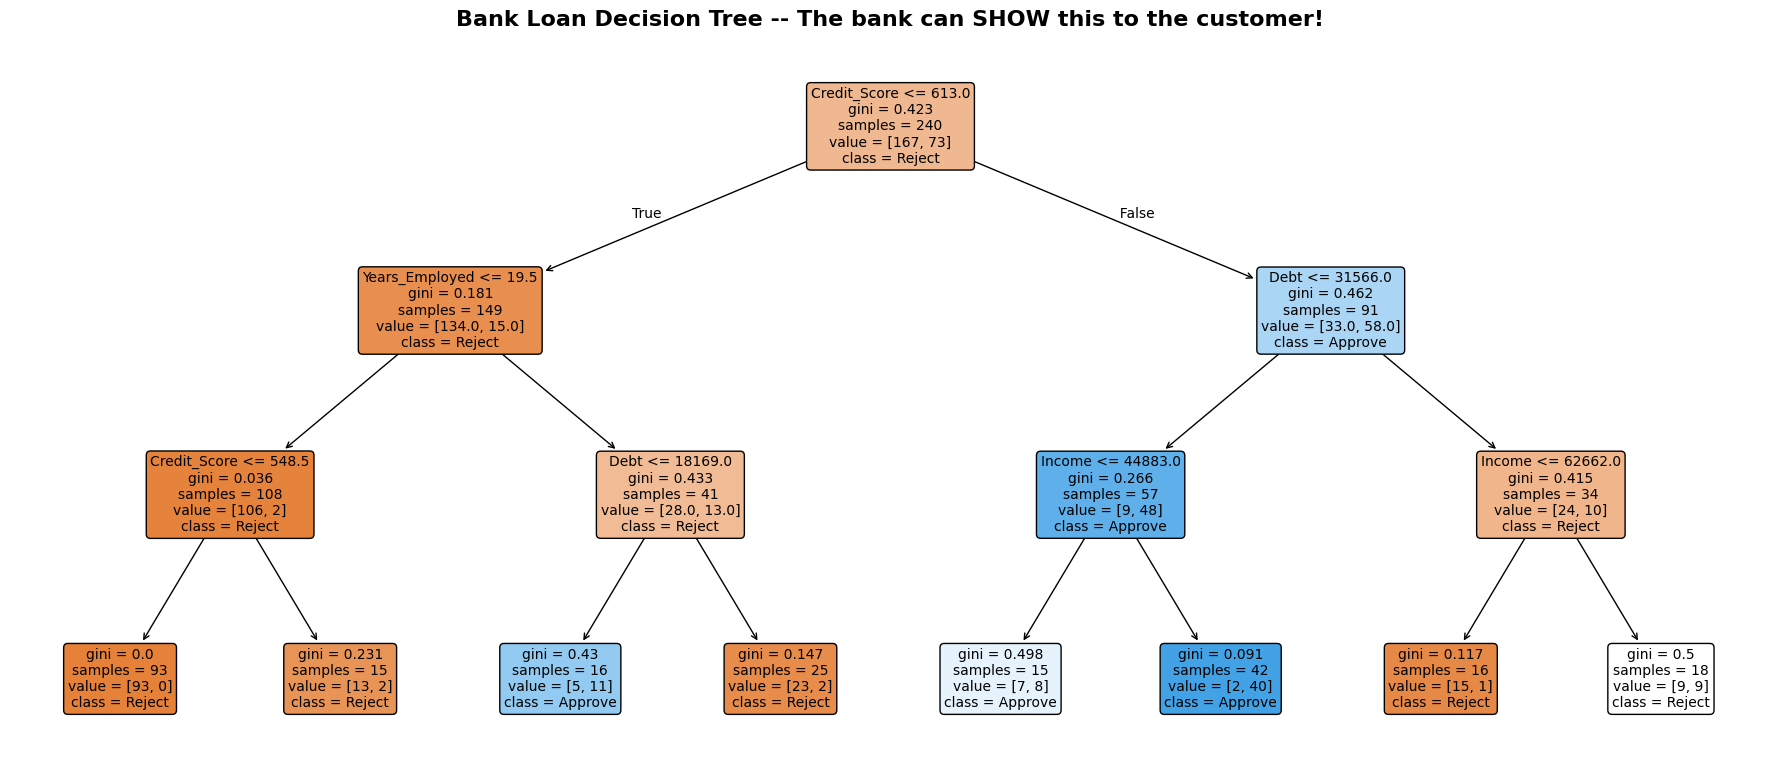


Why Decision Tree for banks?
Because the bank MUST explain to the customer WHY they said no.
With a tree, they can show: "Your credit score was below 600, so we rejected."


In [ ]:
print('=' * 60)
print('EXAMPLE 3: Should we give a loan? (Decision Tree - explainable!)')
print('=' * 60)

np.random.seed(42)
n = 300
income = np.random.randint(15000, 120000, n)
debt = np.random.randint(0, 50000, n)
credit_score = np.random.randint(300, 850, n)
years_employed = np.random.randint(0, 30, n)

approve_score = credit_score * 0.5 + income * 0.001 - debt * 0.005 + years_employed * 5 + np.random.normal(0, 30, n)
approved = (approve_score > 350).astype(int)

loan_X = pd.DataFrame({'Income': income, 'Debt': debt, 'Credit_Score': credit_score, 'Years_Employed': years_employed})
loan_y = approved

X_tr, X_te, y_tr, y_te = train_test_split(loan_X, loan_y, test_size=0.2, random_state=42)

loan_tree = DecisionTreeClassifier(max_depth=3, min_samples_leaf=15, random_state=42)
loan_tree.fit(X_tr, y_tr)
print(f'Accuracy: {accuracy_score(y_te, loan_tree.predict(X_te)):.1%}')

fig, ax = plt.subplots(figsize=(18, 8))
plot_tree(loan_tree, feature_names=list(loan_X.columns), class_names=['Reject', 'Approve'],
          filled=True, rounded=True, fontsize=10, ax=ax)
ax.set_title('Bank Loan Decision Tree -- The bank can SHOW this to the customer!', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nWhy Decision Tree for banks?')
print('Because the bank MUST explain to the customer WHY they said no.')
print('With a tree, they can show: "Your credit score was below 600, so we rejected."')

EXAMPLE 4: Is this transaction fraud? (Random Forest - best accuracy!)
Decision Tree: 96.0%
Random Forest: 96.0%


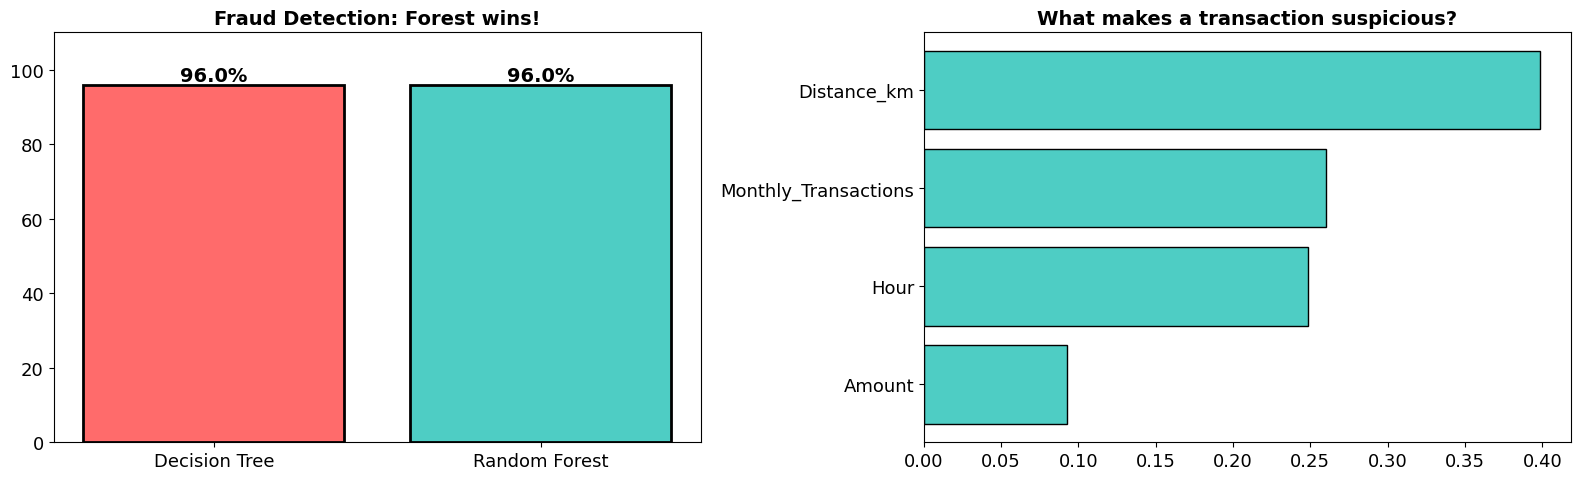


Why Random Forest for fraud?
Because catching fraud requires the HIGHEST accuracy possible.
Missing a fraud transaction can cost the bank millions!


In [ ]:
print('=' * 60)
print('EXAMPLE 4: Is this transaction fraud? (Random Forest - best accuracy!)')
print('=' * 60)

np.random.seed(42)
n = 500
amount = np.random.exponential(100, n)
time_hour = np.random.randint(0, 24, n)
distance = np.random.exponential(50, n)
freq = np.random.randint(1, 50, n)

fraud_score = amount * 0.01 + (time_hour > 22).astype(int) * 20 + distance * 0.1 - freq * 0.5 + np.random.normal(0, 5, n)
is_fraud = (fraud_score > 10).astype(int)

fraud_X = pd.DataFrame({'Amount': amount, 'Hour': time_hour, 'Distance_km': distance, 'Monthly_Transactions': freq})
fraud_y = is_fraud

X_tr, X_te, y_tr, y_te = train_test_split(fraud_X, fraud_y, test_size=0.2, random_state=42)

# Compare Tree vs Forest
fraud_tree = DecisionTreeClassifier(max_depth=4, random_state=42)
fraud_tree.fit(X_tr, y_tr)
tree_acc = accuracy_score(y_te, fraud_tree.predict(X_te))

fraud_forest = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
fraud_forest.fit(X_tr, y_tr)
forest_acc = accuracy_score(y_te, fraud_forest.predict(X_te))

print(f'Decision Tree: {tree_acc:.1%}')
print(f'Random Forest: {forest_acc:.1%}')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

bars = axes[0].bar(['Decision Tree', 'Random Forest'], [tree_acc*100, forest_acc*100],
                   color=['#FF6B6B', '#4ECDC4'], edgecolor='black', lw=2)
axes[0].set_ylim(0, 110)
axes[0].set_title('Fraud Detection: Forest wins!', fontsize=14, fontweight='bold')
for bar, a in zip(bars, [tree_acc*100, forest_acc*100]):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                 f'{a:.1f}%', ha='center', fontsize=14, fontweight='bold')

imp = fraud_forest.feature_importances_
idx = np.argsort(imp)
axes[1].barh(range(len(idx)), imp[idx], color='#4ECDC4', edgecolor='black')
axes[1].set_yticks(range(len(idx)))
axes[1].set_yticklabels([fraud_X.columns[i] for i in idx])
axes[1].set_title('What makes a transaction suspicious?', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()
print('\nWhy Random Forest for fraud?')
print('Because catching fraud requires the HIGHEST accuracy possible.')
print('Missing a fraud transaction can cost the bank millions!')

---

# 🎯 FINAL CHEAT SHEET

| Question | Answer |
|----------|--------|
| **Predict a number?** | Linear Regression |
| **Predict yes/no, simple data?** | Logistic Regression |
| **Predict category + need to explain?** | Decision Tree |
| **Predict category + need best accuracy?** | Random Forest |
| **Need scaling?** | Linear/Logistic = YES. Tree/Forest = NO |
| **Overfitting problem?** | Use pruning (max_depth) or Random Forest |
| **Need to know the math?** | NO! Just know WHEN and WHY to use each model |
| **All models use same code?** | YES! `model.fit()` then `model.predict()` |

---

## Now you can explain Decision Trees, Random Forests, Pruning, and WHEN to use each model!